# 🎓 Personal Writing Assistant Jupyter & Colab Duo
**Notebook developed by** SzuLun Huang <szuh@berkeley.edu>  
**Under the guidance of** Eric Van Dusen <ericvd@berkeley.edu>  
**UC Berkeley, Data Science**

---

### 📌 Compatibility
This notebook runs on **JupyterHub** and **Google Colab** — the environment is detected automatically.

> **Before You Begin:**
> - Run cells **in order** from top to bottom
> - **JupyterHub:** no setup needed — the model is in the shared folder
> - **Colab:** `llama-cpp-python` will be installed automatically on first run (~2–4 min)
> - **All environments:** make sure the model file `Llama-3.2-1B-Instruct-Q4_K_M.gguf` is available before running Step 2

# 🚀 How to Start
1. Click **Kernel** (JupyterHub) or **Runtime** (Colab) in the top menu
2. Select **Restart Kernel and Run All Cells** (JupyterHub) or **Restart session and run all** (Colab)
3. Wait for all cells to finish ⏳
   - **JupyterHub:** ~1–2 minutes (model loading only)
   - **Colab (first run):** ~2–4 minutes (installing dependencies + model loading)
   - **Colab (returning):** ~1–2 minutes (dependencies already installed)
4. Then use the interactive buttons below! ✅

> ⚠️ You only need to do this **once** each time you open the notebook!

### ⚡ Step 0a: Detect Environment

This cell automatically detects whether you are running on
**JupyterHub**, **Google Colab**, or a **local machine**.

> Run this cell first — all subsequent steps depend on `ENV`.



In [1]:
#@title Step 0a: Detect Environment
import os, sys, subprocess

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        pass
    if os.environ.get('JUPYTERHUB_USER') or os.environ.get('JPY_SESSION_NAME'):
        return 'jupyterhub'
    return 'local'

ENV = detect_env()
print(f'Environment detected: {ENV}')

Environment detected: colab


### 📦 Step 0b: Install Dependencies *(Colab only)*

Installs `llama-cpp-python` (CPU version) directly from GitHub.

> **JupyterHub users:** this cell will automatically skip — no action needed.  
> **Colab users:** run this cell once, then restart: **Runtime → Restart session**.  
> Re-running this cell after installation will skip automatically.

In [2]:
# Install llama-cpp-python (CPU version for Colab)
!apt-get install -y musl && \
 ln -sf /usr/lib/x86_64-linux-musl/libc.so /lib/libc.musl-x86_64.so.1 && \
 pip install https://github.com/abetlen/llama-cpp-python/releases/download/v0.3.19/llama_cpp_python-0.3.19-cp312-cp312-linux_x86_64.whl -q

print("✅ Done!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  musl
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 407 kB of archives.
After this operation, 779 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 musl amd64 1.2.2-4 [407 kB]
Fetched 407 kB in 1s (272 kB/s)
Selecting previously unselected package musl:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../musl_1.2.2-4_amd64.deb ...
Unpacking musl:amd64 (1.2.2-4) ...
Setting up musl:amd64 (1.2.2-4) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 681.7 kB/s eta 0:00:00
✅ Done!


In [3]:
#@title Step 0b: Install Dependencies (Colab only)
if ENV == 'colab':
    try:
        from llama_cpp import Llama
        print('llama-cpp-python already installed — skipping.')
    except ImportError:
        print('llama-cpp-python not found — installing CPU version...')
        import subprocess, sys

        # 1. Uninstall any broken versions first
        subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'llama-cpp-python', '-y'],
                       capture_output=True)

        # 2. Install the package directly from PyPI.
        # This allows pip to choose the version compatible with Colab's glibc environment.
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', 'llama-cpp-python', '--no-cache-dir'],
            capture_output=True, text=True
        )

        if result.returncode != 0:
            print('[ERROR] Installation failed:')
            print(result.stderr)
            raise RuntimeError('llama-cpp-python installation failed.')

        print('Installation complete! Please restart the session (Runtime -> Restart session).')

else:
    print(f'Environment is {ENV} — skipping installation.')

llama-cpp-python already installed — skipping.


In [4]:
#@title Step 0c: Model Configuration

model_filename = 'Llama-3.2-1B-Instruct-Q4_K_M.gguf'
n_ctx        = 4096
n_threads    = 4
n_gpu_layers = -1     # -1 = offload all layers to GPU when available

if ENV == 'colab':
    model_path = f'/content/models/{model_filename}'
elif ENV == 'jupyterhub':
    model_path = f'/home/jovyan/shared/{model_filename}'
else:
    model_path = f'./models/{model_filename}'

print(f'Environment  : {ENV}')
print(f'Model        : {model_filename}')
print(f'Path         : {model_path}')
print(f'Context      : {n_ctx} tokens')
print(f'Threads      : {n_threads}')
print(f'GPU layers   : {n_gpu_layers}')

Environment  : colab
Model        : Llama-3.2-1B-Instruct-Q4_K_M.gguf
Path         : /content/models/Llama-3.2-1B-Instruct-Q4_K_M.gguf
Context      : 4096 tokens
Threads      : 4
GPU layers   : -1


In [5]:
#@title Step 0d: Download Model (Colab only)
if ENV == 'colab':
    import subprocess, os

    model_url = 'https://huggingface.co/bartowski/Llama-3.2-1B-Instruct-GGUF/resolve/main/Llama-3.2-1B-Instruct-Q4_K_M.gguf'
    model_output = f'/content/models/{model_filename}'

    if os.path.exists(model_output):
        print('Model already downloaded — skipping.')
    else:
        os.makedirs('/content/models', exist_ok=True)
        print('Downloading model... (this may take 1-3 minutes)')
        subprocess.run(['wget', '-q', '--show-progress', '-O', model_output, model_url])
        print('✅ Model downloaded!')
else:
    print(f'Environment is {ENV} — skipping download.')

✅ Model downloaded!


### 📚 Step 0e: Import Libraries

Imports all required libraries for this notebook.

> ⚠️ Make sure you have run **Step 0a** and **Step 0b** first!

In [6]:
#@title Step 0e: Import Libraries
import time, warnings, json, random, re, math,threading

try:
    import pandas as pd
    import ipywidgets as widgets
    import psutil
    from IPython.display import display, HTML, clear_output
    from llama_cpp import Llama
except ImportError as e:
    print(f'[ERROR] Missing library: {e}')
    print('Make sure Step 0a and Step 0b ran successfully first.')
    raise

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')

All libraries imported successfully.


### 🗺️ Course Roadmap: From Theory to Practice
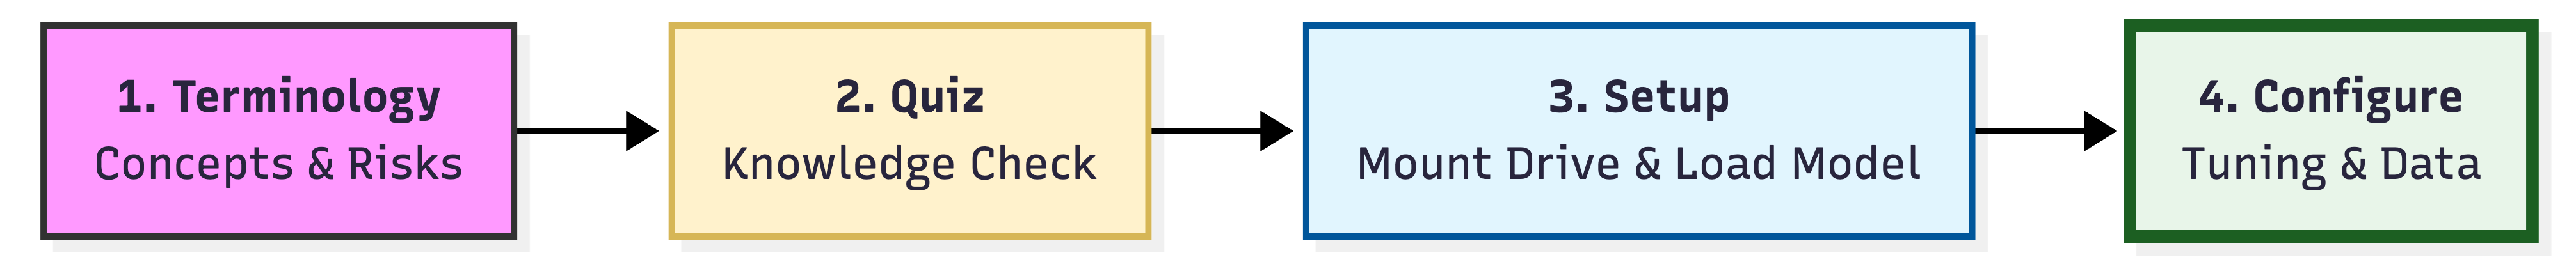


---

## 📘 Part 1: Key Terminology
Before we touch the code, we must master the language of AI.

### **📚 Key Terminology**

| Category | Term | Definition |
| :--- | :--- | :--- |
| **Foundations** | **LLM** | Large Language Models (e.g., GPT-4). The "giant brains" trained on massive datasets. |
| | **AI / SLM** | Artificial Intelligence & Small Language Models (portable, faster versions of LLMs). |
| **Controls** | **Prompt Engineering** | The art of crafting precise instructions for AI. |
| | **Temperature** | 🌡️ Creativity slider: High = Creative; Low = Focused/Stable. |
| | **Few-shot Learning** | 💡 Providing examples to guide the AI's style and format. |
| **Technical** | **Tokens** | 🧱 The units AI reads. Simple words = 1 token; complex words split into sub-pieces (e.g. *unbelievable* → 3 tokens). They define memory and output length. |
| | **Quantization** | A technique to compress models to run on small devices (like Colab). |
| **Risks** | **Hallucination** | When AI generates "fake" information with high confidence. |
| | **Sycophancy** | The tendency of AI to agree with your biases or wrong inputs. |
| **Core Value** | **Human-in-the-loop** | The essential step where **YOU** review and refine the AI's work. |

## **🧱 Tokens: How AI Actually Reads Text**

Tokens are the **"atoms"** of language for LLMs — not words, not characters, not sentences.

**A token can be:**

| Token Type | Example |
|---|---|
| A full word | `cat` → `[cat]` |
| Part of a word (sub-word) | `unbelievable` → `[un]` `[believ]` `[able]` |
| Punctuation | `,` `!` `?` — each its own token |
| Whitespace | the space before `world` attaches to the next token |

**Concrete examples:**

| Text | Likely Tokens | Count |
|---|---|---|
| `cat` | `[cat]` | 1 |
| `hello world` | `[hello]` `[ world]` | 2 |
| `Hello, World!` | `[Hello]` `[,]` `[ World]` `[!]` | 4 |
| `unbelievable` | `[un]` `[believ]` `[able]` | 3 |

> 💡 Simple words = 1 token. Complex words split. Punctuation and whitespace are tokens too — which is why "100 tokens" ≠ "100 words."

In [7]:
#@title 🔍 Interactive Token Visualizer
# ─────────────────────────────────────────────────────────

FILLS = [
    ("#C7DCFF", "#1A4A8A"), ("#C7F7D4", "#0E5C2A"), ("#FFE8C7", "#7A3800"),
    ("#F7D4F7", "#5C0E5C"), ("#FFF9C7", "#5C4A00"), ("#D4F7F7", "#0B5C5C"),
]

def tokenize(text):
    if not text.strip():
        return []
    raw = re.findall(r"(\s*)([A-Za-z]+|[0-9]+|[^\w\s])", text)
    tokens = []
    for space, piece in raw:
        prefix = "·" if space else ""
        if re.match(r"[A-Za-z]{8,}", piece):
            subwords = re.findall(r"[a-z]{2,5}|[A-Z][a-z]{1,4}|[A-Za-z]+", piece)
            if len(subwords) > 1:
                tokens.append(prefix + subwords[0])
                tokens.extend(subwords[1:])
                continue
        tokens.append(prefix + piece)
    return tokens

def get_type(tok):
    core = tok.lstrip("·")
    if re.match(r"^[^\w]+$", core): return "punctuation"
    if re.match(r"^[0-9]+$", core): return "number"
    if tok.startswith("·"):         return "word (space-prefixed)"
    return "word / subword"

def render_viz(tokens):
    if not tokens:
        return ""
    chips = []
    for i, tok in enumerate(tokens):
        bg, fg = FILLS[i % len(FILLS)]
        chips.append(
            f'<span style="background:{bg};color:{fg};border-radius:5px;'
            f'padding:3px 8px;margin:3px 2px;font-family:monospace;'
            f'font-size:13px;display:inline-block;line-height:1.6">{tok}</span>'
        )
    return "".join(chips)

def render_breakdown(tokens, n_words):
    if not tokens:
        return ""
    punct = sum(1 for t in tokens if get_type(t) == "punctuation")
    note  = (
        " Spaces attach to the next token (shown as <code>·</code>) — not a separate token.<br>"
        " <b>Note:</b> This is an approximation. Real tokenizers (like OpenAI's BPE) learn from data —"
        " so <code>unbelievable</code> might be <b>1 token</b> there, not 3, because it appears"
        " often enough to earn its own vocabulary entry."
        " <a href='https://platform.openai.com/tokenizer' target='_blank'"
        " style='color:#1d6fa8'>Compare with the real tokenizer →</a>"
    )
    return (
        f'<div style="font-size:12px;color:#555;border-left:2px solid #ccc;'
        f'padding:6px 10px;margin-top:10px;line-height:1.8">'
        f'<b>{n_words}</b> words → <b>{len(tokens)}</b> tokens'
        f'{"  ·  <b>"+str(punct)+"</b> punctuation tokens" if punct>1 else ("  ·  <b>1</b> punctuation token" if punct==1 else "")}'
        f'<br>{note}'
        f'</div>'
    )

inp = widgets.Textarea(placeholder="Type something here…", layout=widgets.Layout(width="100%", height="90px"))
btn_clear   = widgets.Button(description="Clear",        layout=widgets.Layout(width="90px"))
btn_example = widgets.Button(description="Show example", button_style="primary", layout=widgets.Layout(width="130px"))
btn_try     = widgets.Button(description="Try another",  layout=widgets.Layout(width="110px"))
stat_tokens = widgets.HTML()
stat_chars  = widgets.HTML()
stat_words  = widgets.HTML()
viz_out     = widgets.HTML()
breakdown   = widgets.HTML()

def stat_html(label, value):
    return (f'<div style="font-family:monospace">'
            f'<div style="font-size:12px;color:#888;margin-bottom:2px">{label}</div>'
            f'<div style="font-size:26px;font-weight:500">{value}</div></div>')

def update(_=None):
    text   = inp.value
    tokens = tokenize(text)
    words  = len(text.strip().split()) if text.strip() else 0
    stat_tokens.value = stat_html("Tokens", len(tokens))
    stat_chars.value  = stat_html("Characters", len(text))
    stat_words.value  = stat_html("Words", words)
    viz_out.value   = f'<div style="padding:6px 4px;border-radius:8px;min-height:36px">{render_viz(tokens)}</div>'
    breakdown.value = render_breakdown(tokens, words)

def on_clear(_):   inp.value = "";                                   update()
def on_example(_): inp.value = "Hello, unbelievable world!";        update()
def on_try(_):     inp.value = "Tokens are the atoms of language."; update()

inp.observe(update, names="value")
btn_clear.on_click(on_clear)
btn_example.on_click(on_example)
btn_try.on_click(on_try)

display(HTML("""
<div style="font-family:'IBM Plex Mono',monospace;background:#fff;
    border:1px solid #e0e0e0;border-radius:12px;padding:14px 18px;margin:8px 0">
  <div style="font-size:0.62em;color:#1d6fa8;text-transform:uppercase;
      letter-spacing:0.12em;margin-bottom:6px">Token Visualizer</div>
  <p style="font-size:0.78em;color:#666;margin:0">
    Spaces attach to the <em>next</em> token (shown as <code>·</code>), not a standalone token.
    Punctuation is always its own token.
  </p>
</div>
"""))
display(inp)
display(widgets.HBox([btn_clear, btn_example, btn_try], layout=widgets.Layout(margin="6px 0")))
display(widgets.HBox([stat_tokens, stat_chars, stat_words], layout=widgets.Layout(gap="32px", margin="8px 0")))
display(viz_out, breakdown)
update()

Textarea(value='', layout=Layout(height='90px', width='100%'), placeholder='Type something here…')

HTML(value='')

HTML(value='')

**Why this matters for you:**
* 💰 **Cost** is calculated in tokens (API pricing is per token)
* 📏 **Limits** (context window, max output) are measured in tokens
* 🤖 **Model understanding** happens at the token level — it never sees "unbelievable" as one thing

**Preprocessing** is the step that converts raw text into token IDs — numerical sequences the model can process.
**Pre-training** follows: the model learns from billions of those token sequences to find statistical patterns.

**1. Max Tokens (The Gas Tank)** 🚗 — Your output length limit.
* 50 = 1-2 sentences | 200 = 1 paragraph | 500 = 1 page

**2. Context Window (The Short-term Memory)** 🧠 — How much the AI can "remember" at once.
* 2,048 tokens ≈ 3-4 pages | 4,096 ≈ 6-8 pages | 8,192+ ≈ 12+ pages

> 💡 Too much text? The AI will "forget" the beginning!

---
## **💡 Few-shot Learning: The Power of Examples**
Think of this as **"Monkey see, monkey do."** The fastest way to get personalized results without retraining the model.

### **Zero-shot (No Examples)**
```
Prompt: "Write a professional email."
Output: Generic, formal email with standard structure.
```

### **Few-shot (With Examples)**
```
Prompt:
Example 1: "Hey team! 👋 Quick update: we shipped the new feature today.
Let me know if you spot any bugs!"

Example 2: "Morning everyone! ☀️ Just a heads up – I'll be OOO next Friday.
Hit me up if you need anything before then!"

Your task: Write an email about the upcoming deadline.

Output: Matches your casual tone, emoji usage, and friendly style!
```

### **Why it Matters:**
* **Adapts to YOUR voice**: Writing style, formality, humor, structure
* **No training needed**: Works instantly with just 2-3 examples
* **Highly flexible**: Works for emails, code, creative writing, and more


---
## **🗂️ Quick Recap**

| Concept | One-liner |
|---|---|
| 🧱 **Tokens** | What the model reads — not words, but sub-word pieces |
| 🌡️ **Temperature** | How the model chooses — reshapes the probability distribution |
| ❌ **Hallucination** | Limits of prediction — model fills gaps with confident guesses |

---

## **🎭 Risks: The "Liar" and the "Yes-Man"**

### **❌ Hallucination (The Confident Liar)**
Since AI only predicts the next token based on patterns, it can **confidently invent false information**. Hallucination rates were around 40% on evaluation benchmarks just a year ago. Frontier models today are down to the low teens — improvements came from:
* Training models to say *"I don't know"* rather than guessing
* Larger, more diverse training datasets that give better coverage of edge-case knowledge
* More parameters = broader factual knowledge

> 🔑 **Insider insight:** Modern models are better at *recognizing uncertainty*, not just memorizing more. That shift — from confident guessing to knowing when to say "I don't know" — is the real improvement.

Examples of hallucination:
* Fake dates: "Shakespeare wrote Romeo and Juliet in 1612" (Actually 1597)
* Fake citations: "According to Smith et al. (2023)..." (No such paper exists)

**🛡️ Protection:** Always verify facts, dates, and citations from reliable sources!

### **❌ Sycophancy (The Yes-Man)**
During training, human raters gave higher scores to responses that were encouraging and agreeable — so models learned to *agree* to score well. The unintended consequence: the AI sometimes prioritizes agreeableness over correctness.

* You: "Einstein discovered gravity, right?"
* AI: "Yes, Einstein made significant contributions..." (Wrong! That was Newton)

**🛡️ Protection:** Ask the AI to challenge your assumptions or fact-check your statements.

---

## **⚖️ Core Principle: Human-in-the-Loop (HITL)**
**AI is your co-pilot, not the captain.**

| 🤖 AI provides | 👤 YOU provide |
|---|---|
| Speed & first drafts | Critical thinking |
| Pattern recognition | Fact verification |
| Tireless iteration | Final decisions |

**Never blindly trust AI output — always review, verify, and refine!**

## 🌡️ Temperature in Action

Your friend texts: **"I'm bored."**

How does the AI decide what to reply? At every step, the model calculates a **probability for every possible next token**. Temperature controls how strictly it follows those probabilities.

| Temperature | Behaviour |
|---|---|
| Close to 0 | Almost always picks the highest-probability option |
| 0.5 – 0.7 | Top options dominate, but others get a small chance |
| 1.0+ | Probability spreads out — rarer options start appearing |

> ⚠️ **Important:** Even at high temperature, the most common replies still appear most often. Temperature doesn't flip the ranking — it just flattens the distribution.

👇 Try the slider below — then hit **Generate again** a few times at the same temperature to see how much (or how little) the output varies.

In [8]:
#@title 🌡️ Temperature Demo
# ─────────────────────────────────────────────────────────

# Simulated "logits" — higher score = more probable at low temp
REPLIES = [
    ("Lol same.",                                                              5.0),
    ("Want to grab food?",                                                     4.0),
    ("Let's go for a walk or something.",                                      3.0),
    ("Honestly same, wanna do something spontaneous?",                         2.0),
    ("Ok hear me out — what if we started a business right now",               1.0),
    ("I just googled 'how to become a professional cloud watcher' and I think this is our calling", 0.2),
]

def softmax(logits, temp):
    if temp < 0.01:
        temp = 0.01
    scaled = [l / temp for l in logits]
    max_s  = max(scaled)
    exps   = [math.exp(s - max_s) for s in scaled]
    total  = sum(exps)
    return [e / total for e in exps]

def pick(temp):
    logits = [score for _, score in REPLIES]
    probs  = softmax(logits, temp)
    texts  = [text for text, _ in REPLIES]
    return random.choices(texts, weights=probs, k=1)[0]

def prob_bars(temp):
    logits = [score for _, score in REPLIES]
    probs  = softmax(logits, temp)
    rows   = ""
    for (text, _), p in zip(REPLIES, probs):
        pct = round(p * 100, 1)
        bar_w = round(p * 200)
        rows += (
            f'<tr>'
            f'<td style="font-size:11px;color:#888;padding:2px 8px 2px 0;white-space:nowrap">{pct}%</td>'
            f'<td style="padding:2px 0">'
            f'<div style="background:#C7DCFF;height:10px;width:{bar_w}px;border-radius:3px"></div></td>'
            f'<td style="font-size:11px;color:#555;padding:2px 0 2px 8px">{text}</td>'
            f'</tr>'
        )
    return f'<table style="border-collapse:collapse;margin-top:8px">{rows}</table>'

def label(temp):
    if temp < 0.3:   return "🧮 Near-deterministic — almost always picks the top option"
    elif temp < 0.7: return "⭐ Balanced — top options dominate but others get a chance"
    elif temp < 1.0: return "🎨 Creative — probability spreads out more evenly"
    else:            return "⚠️ High — even the weird options become likely"

slider = widgets.FloatSlider(
    value=0.7, min=0.1, max=2.0, step=0.1,
    description="Temp:", readout_format=".1f",
    layout=widgets.Layout(width="100%")
)
btn = widgets.Button(description="Generate again", button_style="primary",
                     layout=widgets.Layout(width="130px"))
out = widgets.HTML()

def update(_=None):
    t = slider.value
    result = pick(t)
    out.value = (
        f'<div style="margin-top:12px;font-family:monospace;background:#f8f8f8;'
        f'border-radius:8px;padding:12px 16px;font-size:14px">{result}</div>'
        f'<div style="margin-top:8px;font-size:12px;color:#555;'
        f'border-left:2px solid #ccc;padding:4px 10px">{label(t)}</div>'
        f'<details style="margin-top:10px;font-size:12px;color:#555;cursor:pointer">'
        f'<summary>Show probability distribution</summary>'
        f'{prob_bars(t)}'
        f'</details>'
        f'<div style="margin-top:6px;font-size:11px;color:#aaa">'
        f'💡 Try "Generate again" at the same temperature — does it change?</div>'
    )

slider.observe(update, names="value")
btn.on_click(update)

display(HTML(
    '<p style="font-size:13px;color:#555;margin-bottom:6px">'
    'Your friend texts: <strong>"I\'m bored."</strong> — '
    'how does the AI reply at different temperatures?</p>'
))
display(slider)
display(btn)
display(out)
update()

FloatSlider(value=0.7, description='Temp:', layout=Layout(width='100%'), max=2.0, min=0.1, readout_format='.1f…

Button(button_style='primary', description='Generate again', layout=Layout(width='130px'), style=ButtonStyle()…

HTML(value='')

## 🧪 Spot the Hallucination

Which answer is safer?

> **Q:** *"What is the population of Mars?"*


**Answer A:**
> "Mars has a population of about 3 million people living in underground cities."

**Answer B:**
> "Mars does not have a human population. It is currently uninhabited."


👉 Which one is correct?
👉 Why might a model produce Answer A?

<details>
<summary>✅ Click to reveal</summary>

**Correct answer: B**

**Why hallucination happens:**
- The model predicts *plausible* text — not verified facts
- It prefers fluent, confident answers over "I don't know"
- "Underground cities on Mars" sounds plausible if you've seen sci-fi

**Why modern models are better:**
- They're trained to say *"I'm not sure"* or *"That's not known"*
- Recognizing uncertainty is the real improvement — not just memorizing more facts

</details>


In [9]:
#@title 🎓 Part 2: AI Control Quiz - Random 5 Questions
# ──────────────────────────────────────────────────────


question_bank = [
    {"q": "Which temperature setting is best for writing a creative poem?",
     "options": ["0.2 (The Accountant)", "0.7 (The Journalist)", "1.0 (The Poet)", "2.0 (The Chaos)"],
     "answer": "1.0 (The Poet)", "hint": "You want creativity, but it should still make sense!"},
    {"q": "You need to extract exact dates from a legal document. What temperature?",
     "options": ["0.2 (The Accountant)", "0.7 (The Journalist)", "1.0 (The Poet)", "1.5+ (The Chaos)"],
     "answer": "0.2 (The Accountant)", "hint": "You want precision and safety, not creativity!"},
    {"q": "What happens when temperature is set to 2.0?",
     "options": ["More precise output", "Faster generation", "Chaotic and nonsensical text", "Better grammar"],
     "answer": "Chaotic and nonsensical text", "hint": "Very high temperature = too much randomness!"},
    {"q": "You're writing a professional business email. What's the ideal temperature?",
     "options": ["0.2", "0.7-0.9", "1.2", "1.8"],
     "answer": "0.7-0.9", "hint": "The 'Journalist' zone - professional and natural!"},
    {"q": "What happens if max_tokens is set too low?",
     "options": ["AI will write faster", "AI will cut off mid-sentence", "AI will be more creative", "Nothing changes"],
     "answer": "AI will cut off mid-sentence", "hint": "It's like running out of gas!"},
    {"q": "Approximately how many English words is 100 tokens?",
     "options": ["25 words", "75 words", "100 words", "200 words"],
     "answer": "75 words", "hint": "Tokens are sub-word pieces — simple words = 1 token, complex words split further. 100 tokens ≈ 75 words is a rough average, but what really matters is the sub-word structure!"},
    {"q": "You're summarizing a 20-page document, but the AI keeps 'forgetting' the beginning. What's the problem?",
     "options": ["Temperature too high", "Context Window too small", "Max Tokens too low", "Hallucination"],
     "answer": "Context Window too small", "hint": "Think about the AI's 'Short-term Memory' limit!"},
    {"q": "What is the Context Window?",
     "options": ["The output length limit", "How much the AI can remember (input + output)", "The AI's training data", "The response speed"],
     "answer": "How much the AI can remember (input + output)", "hint": "It's the AI's short-term memory capacity!"},
    {"q": "In Few-shot learning, how many examples do you typically need?",
     "options": ["0 examples", "2-3 examples", "50+ examples", "Thousands of examples"],
     "answer": "2-3 examples", "hint": "Remember: 'Monkey see, monkey do' - you don't need many!"},
    {"q": "What's the difference between zero-shot and few-shot prompting?",
     "options": ["Zero-shot is faster", "Few-shot provides examples, zero-shot doesn't", "Zero-shot is more accurate", "There's no difference"],
     "answer": "Few-shot provides examples, zero-shot doesn't", "hint": "Few-shot = showing examples; Zero-shot = just asking"},
    {"q": "You want the AI to match YOUR specific writing style. What's the best approach?",
     "options": ["Use high temperature", "Provide 2-3 examples of your writing (few-shot)", "Use more max_tokens", "Ask it to 'write like me'"],
     "answer": "Provide 2-3 examples of your writing (few-shot)", "hint": "Show, don't tell!"},
    {"q": "The AI tells you 'Shakespeare wrote Romeo and Juliet in 1612.' What is this?",
     "options": ["Quantization", "Hallucination", "Sycophancy", "Few-shot learning"],
     "answer": "Hallucination", "hint": "The AI is being a 'Confident Liar'! (It was actually 1597)"},
    {"q": "What is AI hallucination?",
     "options": ["When AI generates images", "When AI invents false information confidently", "When AI is too creative", "When AI refuses to answer"],
     "answer": "When AI invents false information confidently", "hint": "It's when the AI makes up 'facts'!"},
    {"q": "How can you protect against hallucinations?",
     "options": ["Use higher temperature", "Always verify facts from reliable sources", "Use more tokens", "Disable few-shot learning"],
     "answer": "Always verify facts from reliable sources", "hint": "Never blindly trust AI output!"},
    {"q": "You say 'Einstein discovered gravity, right?' and the AI agrees. What is this?",
     "options": ["Hallucination", "Sycophancy", "Zero-shot learning", "High temperature effect"],
     "answer": "Sycophancy", "hint": "The AI is being a 'Yes-Man' - Newton discovered gravity!"},
    {"q": "What is sycophancy in AI?",
     "options": ["AI being too creative", "AI agreeing with you even when you're wrong", "AI refusing to help", "AI being too slow"],
     "answer": "AI agreeing with you even when you're wrong", "hint": "It's the 'Yes-Man' behavior!"},
    {"q": "What does HITL (Human-in-the-Loop) mean?",
     "options": ["AI makes all final decisions", "Humans verify and guide AI output", "AI works without human input", "Humans only provide initial prompts"],
     "answer": "Humans verify and guide AI output", "hint": "You're the Captain, AI is the Co-pilot!"},
    {"q": "In the HITL principle, who is responsible for final decisions?",
     "options": ["The AI", "The human", "Both equally", "Neither"],
     "answer": "The human", "hint": "AI is the co-pilot, YOU are the captain!"},
    {"q": "Which model are we using in this notebook?",
     "options": ["ChatGPT", "Claude", "Llama (via Llama.cpp)", "GPT-4"],
     "answer": "Llama (via Llama.cpp)", "hint": "Check the top of the notebook!"},
    {"q": "What is Llama.cpp?",
     "options": ["An AI model", "A tool to run LLMs locally", "A cloud service", "A programming language"],
     "answer": "A tool to run LLMs locally", "hint": "It's a lightweight inference engine, not a model!"},
]


root = widgets.Output()
display(root)

def build_quiz():

    global question_bank, root
    selected_questions = random.sample(question_bank, 5)
    radio_widgets = []
    for item in selected_questions:
        w = widgets.RadioButtons(
            options=item["options"],
            description='',
            disabled=False,
            layout={'width': 'max-content'}
        )
        radio_widgets.append(w)

    result_output = widgets.Output()

    def on_submit(b):
        with result_output:
            clear_output()
            score = 0
            lines = ["<hr>"]
            for i, w in enumerate(radio_widgets):
                if w.value == selected_questions[i]["answer"]:
                    score += 1
                    lines.append(f"<p>✅ <b>Question {i+1}:</b> Correct!</p>")
                else:
                    lines.append(
                        f"<p>❌ <b>Question {i+1}:</b> Wrong.<br>"
                        f"&nbsp;&nbsp;💡 Hint: {selected_questions[i]['hint']}<br>"
                        f"&nbsp;&nbsp;✓ Correct answer: <b>{selected_questions[i]['answer']}</b></p>"
                    )
            percentage = (score / len(selected_questions)) * 100
            lines.append(f"<hr><h3>📊 Final Score: {score}/{len(selected_questions)} ({percentage:.0f}%)</h3>")
            if score == 5:
                lines.append("<h2 style='color:#2e7d32;'>🏆 Perfect Score! You're an AI Control Expert!</h2>")
            elif score >= 4:
                lines.append("<h2 style='color:#1976d2;'>👍 Great Job! You understand the fundamentals well!</h2>")
            elif score >= 3:
                lines.append("<h2 style='color:#f57c00;'>📚 Good Start! Review the material and try again!</h2>")
            else:
                lines.append("<h2 style='color:#c62828;'>🔄 Keep Learning! Go back to the Deep Dive section!</h2>")
            display(HTML("".join(lines)))

    def on_retry(b):

        with root:
            clear_output(wait=True)
        build_quiz()

    submit_btn = widgets.Button(description="Submit Answers", button_style='primary', icon='check')
    retry_btn  = widgets.Button(description="Try Again",      button_style='info',    icon='refresh')
    submit_btn.on_click(on_submit)
    retry_btn.on_click(on_retry)

    header = widgets.HTML("""
        <h2>🎓 Part 2: AI Control Quiz - Random 5 Questions</h2>
        <p style='font-size:14px;color:#666;'>📝 5 random questions from a bank of 20 | Click 'Try Again' for new questions!</p>
        <hr>
    """)

    question_widgets = []
    for i, item in enumerate(selected_questions):
        question_widgets.append(
            widgets.HTML(f"<p style='font-weight:bold;margin-top:15px;'>{i+1}. {item['q']}</p>")
        )
        question_widgets.append(radio_widgets[i])

    quiz_box = widgets.VBox(
        [header] + question_widgets + [widgets.HBox([submit_btn, retry_btn]), result_output]
    )

    with root:
        display(quiz_box)

build_quiz()


Output()

# **✍️ Part 3: Build Your Personal Writing Assistant**

> Now that you understand the theory, it's time to build something real!  
> In this section, you will set up your AI step by step.

---

## 🗺️ Steps Overview

| Step | What You'll Do |
|---|---|
| 📥 Step 1 | RAM Check |
| 🔧 Step 2 | Load the model into memory |
| 💬 Step 3a | Say hello (no system prompt) |
| ✅ Step 3b | Test with your custom system prompt |
| 🎓 Step 3c | Real-World System Prompt Examples |
| ✍️ Step 4 | Use the full Writing Assistant |
| 🎯 Step 5a | Teach the AI your writing style |
| 🎛️ Step 5b | Experiment with AI parameters |
| 📊 Step 5c | Compare your experiment results |

> ⚠️ **Important:** Run cells **in order** from top to bottom!

### Step 1: RAM Check

In [10]:
#@title RAM Check
ram = psutil.virtual_memory()
print(f"💾 System RAM:  {ram.total / 1e9:.1f} GB total")
print(f"   Available:   {ram.available / 1e9:.1f} GB free")
print(f"   Used:        {ram.used / 1e9:.1f} GB ({ram.percent}%)")

if ram.available / 1e9 < 2:
    print("\n⚠️  Warning: Less than 2GB available — model may run slowly.")
else:
    print("\n✅ RAM looks good!")

💾 System RAM:  13.6 GB total
   Available:   12.6 GB free
   Used:        0.7 GB (7.7%)

✅ RAM looks good!



### 🔧 Step 2: Load AI Model

### ⚠️ Make sure you ran Step 1 first!

In [11]:
#@title Verify and Load Model

if not os.path.exists(model_path):
    if ENV == 'colab':
        msg = (f'Model not found at {model_path}.\n'
               'Please re-run Step 0a to download the model.')
    elif ENV == 'jupyterhub':
        msg = (f'Model not found at {model_path}.\n'
               'Ask your instructor to check the shared folder.')
    else:
        msg = f'Model not found at {model_path}. Check your local models/ directory.'
    print(f'❌ {msg}')
    raise FileNotFoundError(msg)

size_gb = os.path.getsize(model_path) / (1024**3)
print(f'✅ Found  {model_filename}  ({size_gb:.2f} GB)')
print('⏳ Loading model…  (this may take 1-2 minutes)\n')

t0    = time.time()
model = Llama(
    model_path   = model_path,
    n_ctx        = n_ctx,
    n_threads    = n_threads,
    n_gpu_layers = n_gpu_layers,
    verbose      = False,
)
elapsed = time.time() - t0

clear_output(wait=True)
print('=' * 50)
print(f'✅ Model loaded and ready!  ({elapsed:.1f}s on {ENV})')
print('=' * 50)

✅ Model loaded and ready!  (1.2s on colab)


### 💬 Step 3a: Say Hello to Your AI
#### ⚠️ Make sure you ran Step 1 and Step 2 first!

This cell sends your **first message** to the AI — but with a deliberate flaw.

## 🧪 Spot the Problem
> ⚠️ **Notice something strange?**  
> Without a `system prompt`, the model has **no fixed identity**.  
> Sometimes it says it's an AI — but sometimes it invents a human persona like "Emily" or "Sarah".  
> The output is **unpredictable and inconsistent**.

**Your job:** Run the cell **2-3 times** and observe:
- Does the answer change each time?
- Does it ever claim to be a human with a name?

We will fix this in **Step 3b** by adding a system prompt.

In [12]:
#@title Step 3a: Say Hello to Your AI (No System Prompt)

display(HTML("""
<style>
/* ── Catppuccin Mocha ── */
.widget-dropdown select {
    background: #f5f5f5 !important;
    color: #1a1a2e !important;
    border: 1px solid #d1d5db !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 4px 8px !important;
}
.widget-dropdown select:focus {
    border-color: #1d6fa8 !important;
    outline: none !important;
}
.widget-textarea textarea {
    background: #f5f5f5 !important;
    color: #1a1a2e !important;
    border: 1px solid #d1d5db !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 8px 10px !important;
    resize: vertical !important;
}
.widget-textarea textarea:focus {
    border-color: #1d6fa8 !important;
    outline: none !important;
}
.widget-textarea textarea::placeholder {
    color: #6b7280 !important;
}
.widget-text input[type="text"] {
    background: #f5f5f5 !important;
    color: #1a1a2e !important;
    border: 1px solid #d1d5db !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 4px 8px !important;
}
.widget-text input[type="text"]:focus {
    border-color: #1d6fa8 !important;
    outline: none !important;
}
.widget-label, .widget-label-basic {
    color: #374151 !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
}
.widget-button.mod-warning {
    background: #f9e2af !important;
    color: #1a1a2e !important;
    border: none !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-weight: bold !important;
}
.widget-button.mod-primary {
    background: #89b4fa !important;
    color: #1a1a2e !important;
    border: none !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-weight: bold !important;
}
.widget-button.mod-primary:hover,
.widget-button.mod-warning:hover {
    filter: brightness(1.1) !important;
    cursor: pointer !important;
}
.widget-button.mod-primary:disabled {
    background: #e5e7eb !important;
    color: #6b7280 !important;
}
</style>
"""))

progress_out = widgets.Output()
result_out   = widgets.Output()
run_btn = widgets.Button(
    description  = "▶ Test Model",
    button_style = "warning",
    layout       = widgets.Layout(width="160px", margin="10px 0")
)

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #d1d5db;
            border-radius:12px;padding:18px 20px;margin:10px 0;color:#1a1a2e">
  <div style="font-size:0.63em;color:#c2185b;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 3a — Intentional Flaw</div>
  <h3 style="color:#1a1a2e;margin:0 0 14px;font-size:1.0em">💬 Say Hello to Your AI</h3>
  <div style="background:#f5f5f5;border-left:3px solid #c2185b;border-radius:0 6px 6px 0;
              padding:10px 14px;font-size:0.78em;color:#d84315;
              display:flex;align-items:flex-start;gap:8px">
    <span>⚠️</span>
    <span>No system prompt is used here — observe what happens to the model's identity.</span>
  </div>
</div>
"""))
display(run_btn, progress_out, result_out)

def on_run(_):
    run_btn.disabled    = True
    run_btn.description = "⏳ Running..."
    with progress_out: clear_output()
    with result_out:   clear_output()

    timer_output = widgets.Output()
    with progress_out:
        display(HTML("""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #d1d5db;
                    border-radius:12px;padding:18px 20px;margin-top:10px;color:#1a1a2e">
          <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Generating...</div>
          <div style="font-size:0.82em;color:#374151;">
            🤖 Model is thinking... please wait...
          </div>
        </div>
        """))
        display(timer_output)

    start_time = time.time()
    result_container = {}

    def run_model():
        try:
            response = model(
                "Please introduce yourself in 2-3 sentences. Who are you and what can you help with?",
                max_tokens=100,
                temperature=0.7,
                echo=False
            )
            result_container["result"] = response["choices"][0]["text"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except NameError:
            result_container["error"] = "name"
        except Exception as e:
            result_container["error"] = str(e)

    thread = threading.Thread(target=run_model)
    thread.start()

    # ── Hatching chick countdown ──────────────────────────────
    total = 10
    while thread.is_alive():
        elapsed  = int(time.time() - start_time)
        remaining = max(0, total - elapsed)
        progress  = min(elapsed / total, 1.0)

        if progress < 0.25:
            emoji = "🥚"
            msg   = "Warming up the egg..."
            color = "#f9e2af"
        elif progress < 0.5:
            emoji = "🥚💥"
            msg   = "Something is moving inside..."
            color = "#d84315"
        elif progress < 0.75:
            emoji = "🐣"
            msg   = "Almost there..."
            color = "#16a34a"
        else:
            emoji = "🐥"
            msg   = "Coming out!"
            color = "#0e7490"

        bar_filled = int(progress * 20)
        bar = "🟡" * bar_filled + "⬜" * (20 - bar_filled)

        with timer_output:
            clear_output(wait=True)
            display(HTML(
                f'<div style="font-family:\'IBM Plex Mono\',monospace;'
                f'padding:12px 0;font-size:1.1em;text-align:left;">'
                f'<span style="font-size:2em">{emoji}</span><br>'
                f'<span style="color:{color};font-weight:bold;">{msg}</span><br>'
                f'<span style="font-size:0.8em;color:#374151;">⏳ {remaining} sec remaining</span><br>'
                f'<span style="letter-spacing:1px;font-size:0.85em">{bar}</span>'
                f'</div>'
            ))
        time.sleep(1)

    # Hatched!
    with timer_output:
        clear_output(wait=True)
        display(HTML(
            '<div style="font-family:\'IBM Plex Mono\',monospace;'
            'padding:12px 0;font-size:1.1em;">'
            '<span style="font-size:2em">🐔✨</span><br>'
            '<span style="color:#16a34a;font-weight:bold;">Ready! The chick has hatched!</span>'
            '</div>'
        ))
    time.sleep(0.5)

    elapsed = int(time.time() - start_time)
    with progress_out: clear_output()

    if "error" in result_container:
        err = result_container["error"]
        if err == "name":
            result = "❌ model not found!\n💡 Please run Step 0 first!"
        else:
            result = f"❌ Error: {err}\n\n💡 Try running Step 0 again."
        accent = "#c2185b"
        status = "❌ Error"
    else:
        result = result_container["result"]
        accent = "#16a34a"
        status = "⚠️ Done — spot the problem!"

    tokens = result_container.get("tokens", 0)

    with result_out:
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #d1d5db;
                    border-radius:12px;padding:18px 20px;margin-top:10px;color:#1a1a2e">
          <div style="font-size:0.63em;color:{accent};text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Output — {status}</div>
          <h3 style="color:#1a1a2e;margin:0 0 14px;font-size:1.0em">🤖 AI says:</h3>
          <div style="background:#f5f5f5;border:1px solid #313244;border-radius:8px;
                      padding:14px 16px;font-size:0.82em;color:#1a1a2e;line-height:1.9">
            {result.replace(chr(10), '<br>')}
          </div>
          <div style="margin-top:12px;font-size:0.72em;color:#6b7280;font-family:'IBM Plex Mono',monospace">
            📊 Tokens used: <span style="color:{accent};font-weight:bold">{tokens}</span> / 100
            &nbsp;|&nbsp;
            ⏱️ Generated in: <span style="color:{accent};font-weight:bold">{elapsed} sec</span>
          </div>
          <div style="margin-top:10px;background:#f5f5f5;border-left:3px solid #89b4fa;
                      border-radius:0 6px 6px 0;padding:8px 12px;font-size:0.78em;color:#1d6fa8">
            🤔 Does the AI claim to be a human? Run again — does the name change?
          </div>
        </div>
        """))

    run_btn.disabled    = False
    run_btn.description = "▶ Run Again"

run_btn.on_click(on_run)

Button(button_style='warning', description='▶ Test Model', layout=Layout(margin='10px 0', width='160px'), styl…

Output()

Output()

## **🎭 What is a System Prompt?**

> Before we test the AI, let's learn one important concept!

Think of it like this:

| Without System Prompt | With System Prompt |
|---|---|
| Actor with no script 🎭 | Actor with a clear role 🎬 |
| AI improvises freely | AI knows exactly who it is |
| Unpredictable results | Consistent and focused |

### **Examples:**
* `"You are a helpful writing assistant"` → Professional AI helper
* `"You are a pirate"` → Arrr, I'll help ye write! 🏴‍☠️
* `"You are a strict grammar teacher"` → Focuses only on grammar

**System Prompt = Your AI's job description!**

---
### 👇 Run the cell below to see the difference in action!

### Step 3b: Now WITH a System Prompt

In Step 3a, the AI had **no identity** — it made up a random persona.

Now let's fix that by giving the AI a **system prompt**: a set of instructions that tells it exactly who it is and what it should do.

> 💡 **How it works:**  
> You define the AI's **role** and **capabilities** below.  
> The model will read your instructions before answering — and stick to them.

Try changing the role to something fun:
- `"a friendly cooking chef"`
- `"a wise history teacher"`  
- `"a funny joke-telling robot"`

Then click **▶️ Test System Prompt** and compare with Step 3a!

In [13]:
#@title Step 3b: Now WITH System Prompt

role_input_3b = widgets.Text(
    value="a helpful AI tutor for UC Berkeley students",
    description="",
    layout={"width": "500px"}
)
capabilities_input_3b = widgets.Text(
    value="answer questions, explain concepts, and give examples",
    description="",
    layout={"width": "500px"}
)
run_btn_3b = widgets.Button(
    description="Loading model...",
    button_style="primary",
    disabled=True,
    layout={"width": "220px", "height": "40px"}
)
output_area_3b = widgets.Output()

display(HTML("""
<style>
.widget-text input[type="text"] {
    background: #f5f5f5 !important;
    color: #374151 !important;
    border: 1px solid #e5e7eb !important;
    border-radius: 4px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 4px 8px !important;
}
.widget-text input[type="text"]:focus {
    border-color: #1d6fa8 !important;
    outline: none !important;
}
.jupyter-widgets.widget-button.mod-primary,
button.mod-primary {
    background: #1d6fa8 !important;
    color: #ffffff !important;
    border: none !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-weight: bold !important;
    box-shadow: none !important;
}
.jupyter-widgets.widget-button.mod-primary:hover,
button.mod-primary:hover {
    filter: brightness(1.1) !important;
    cursor: pointer !important;
}
</style>

<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#f9fafb;border:1px solid #e5e7eb;
            border-radius:12px;padding:18px 20px;margin:10px 0;color:#374151">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 3b - With System Prompt</div>
  <h3 style="color:#374151;margin:0 0 10px;font-size:1.0em">Customize Your AI's Identity</h3>
  <div style="background:#f5f5f5;border-left:3px solid #1d6fa8;
              border-radius:0 6px 6px 0;padding:10px 14px;
              font-size:0.78em;color:#6b7280;line-height:1.8">
    Edit the fields below, then click
    <span style="color:#1d6fa8;font-weight:bold">Test System Prompt</span>
    to see how the AI introduces itself differently!
  </div>
</div>
"""))

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:10px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  AI Role:
</div>"""))
display(role_input_3b)

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:8px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  Can Help With:
</div>"""))
display(capabilities_input_3b)

display(HTML("<div style='margin:10px 0 4px'></div>"))
display(run_btn_3b, output_area_3b)

if 'model' not in dir():
    model = Llama(
        model_path='/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf',
        n_ctx=4096,
        verbose=False
    )

run_btn_3b.disabled    = False
run_btn_3b.description = "Test System Prompt"


def on_run_3b(b):
    global model

    run_btn_3b.disabled    = True
    run_btn_3b.description = "Running..."

    role          = role_input_3b.value
    capabilities  = capabilities_input_3b.value
    system_prompt = f"You are {role}. You help users with {capabilities}."
    llm           = model

    with output_area_3b:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#f9fafb;border:1px solid #e5e7eb;
                    border-radius:12px;padding:18px 20px;margin-top:10px;color:#374151">
          <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Generating...</div>
          <div style="background:#f5f5f5;border:1px solid #e5e7eb;border-radius:8px;
                      padding:10px 14px;font-size:0.8em;color:#1d6fa8;font-style:italic">
            System prompt: "{system_prompt}"
          </div>
          <div style="margin-top:10px;font-size:0.82em;color:#6b7280">
            Model is thinking... (~20 sec)
          </div>
        </div>
        """))

    result_container = {}

    def run_model():
        try:
            response = llm.create_chat_completion(
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": "Please introduce yourself in 2-3 sentences. Who are you and what can you help with?"}
                ],
                max_tokens=100,
                temperature=0.7,
            )
            result_container["result"] = response["choices"][0]["message"]["content"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except Exception as e:
            result_container["error"] = f"{type(e).__name__}: {e}"

    t = threading.Thread(target=run_model)
    t.start()
    t.join()

    if "error" in result_container:
        result = f"Error: {result_container['error']}"
        accent, status, tokens = "#c2185b", "Error", 0
    else:
        result = result_container["result"]
        tokens = result_container.get("tokens", 0)
        accent, status = "#16a34a", "Done"

    with output_area_3b:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#f9fafb;border:1px solid #e5e7eb;
                    border-radius:12px;padding:18px 20px;margin-top:10px;color:#374151">
          <div style="font-size:0.63em;color:{accent};text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Output - {status}</div>
          <div style="background:#f5f5f5;border-left:3px solid #1d6fa8;
                      border-radius:0 6px 6px 0;padding:10px 14px;
                      margin-bottom:12px;font-size:0.78em;color:#1d6fa8">
            System Prompt:
            <div style="font-style:italic;margin-top:4px;color:#6b7280">"{system_prompt}"</div>
          </div>
          <div style="background:#f5f5f5;border:1px solid #e5e7eb;border-radius:8px;
                      padding:14px 16px;font-size:0.82em;color:#374151;line-height:1.9;
                      white-space:pre-wrap">{result.replace(chr(10), '<br>')}</div>
          <div style="margin-top:12px;font-size:0.72em;color:#6b7280;font-family:'IBM Plex Mono',monospace">
            Tokens used: <span style="color:{accent};font-weight:bold">{tokens}</span>/100
          </div>
          <div style="margin-top:10px;background:#f5f5f5;border-left:3px solid #16a34a;
                      border-radius:0 6px 6px 0;padding:8px 12px;font-size:0.78em;color:#16a34a">
            Notice the difference from Step 3a? The AI now has a consistent identity!
            Try changing the role and click again!
          </div>
        </div>
        """))

    run_btn_3b.disabled    = False
    run_btn_3b.description = "Run Again"


run_btn_3b.on_click(on_run_3b)

Text(value='a helpful AI tutor for UC Berkeley students', layout=Layout(width='500px'))

Text(value='answer questions, explain concepts, and give examples', layout=Layout(width='500px'))

Button(button_style='primary', description='Loading model...', disabled=True, layout=Layout(height='40px', wid…

Output()

### Step 3c 🎓 Real-World System Prompt Examples

> Professor Van Dusen teaches both **Data 8** (intro) and **Data 100** (advanced).  
> Watch how the *same question* gets a completely different answer depending on the system prompt!

| Context | System Prompt Strategy |
|---|---|
| 📗 **Data 8 student** | Assume no prior coding knowledge. Use analogies, avoid jargon. |
| 📘 **Data 100 student** | Assume familiarity with pandas, numpy, and statistics. Be concise. |
| 📊 **Econ student** | Frame everything in terms of supply/demand, regression, or policy. |
| 👨‍🏫 **Professor Van Dusen** | You ARE the professor — give feedback on a student's analysis. |

Try the interactive cell below to see the difference! 👇


In [14]:
#@title System Prompt Showcase — Data 8 vs Data 100 vs Econ & Prof. Eric

PERSONAS = {
    "📗 Data 8 TA (Intro, no coding background)": (
        "You are a teaching assistant for a complete beginner who just entered college. "
        "They have NEVER written a single line of code before. "
        "You MUST use simple everyday analogies — no jargon at all. "
        "Example: explain a for-loop like a daily morning routine. "
        "Keep answers short, friendly, and under 3 sentences. No code."
    ),
    "📘 Data 100 TA (Advanced, knows pandas & stats)": (
        "You are a teaching assistant for a second-year university student "
        "who is already comfortable with Python, pandas, and basic statistics. "
        "NEVER explain basics. Go straight to the technical details. "
        "Mention edge cases and efficiency. "
        "Be concise and precise — maximum 3 sentences. No code blocks."
    ),
    "📊 Econ 1 TA (Economics framing)": (
        "You are an economics professor who ONLY thinks in terms of money, markets, and incentives. "
        "Connect EVERY answer to a real economic example involving prices, wages, or GDP. "
        "Always end with one policy implication. "
        "Maximum 3 sentences total. No code, no programming examples."
    ),
    "👨‍🏫 Professor Eric Van Dusen (giving feedback)": (
        "You are Professor Eric Van Dusen from UC Berkeley, a warm and encouraging mentor "
        "who genuinely cares about every student's growth. "
        "Respond like a real conversation — personal, supportive, enthusiastic about data science. "
        "Acknowledge what's good, then gently guide toward deeper understanding. "
        "Keep it to 3 sentences maximum. No bullet points, no code."
    ),
}

SAMPLE_QUESTIONS = [
    "What is a for-loop? Give me a simple example.",
    "How does linear regression work?",
    "Why do we need a test/train split in machine learning?",
    "What is the difference between correlation and causation?",
    "How would I analyze whether a policy had an effect?",
]

W = "660px"

persona_dropdown_3c = widgets.Dropdown(
    options=list(PERSONAS.keys()),
    description="",
    layout={"width": W}
)
system_preview_3c = widgets.HTML(value="")
sample_q_dropdown_3c = widgets.Dropdown(
    options=["(Pick a sample question or type your own below)"] + SAMPLE_QUESTIONS,
    description="",
    layout={"width": W}
)
question_input_3c = widgets.Textarea(
    placeholder="Type a question here, or select a sample above...",
    description="",
    layout={"width": W, "height": "80px"}
)
generate_btn_3c = widgets.Button(
    description="🚀 Ask this Persona",
    button_style="primary",
    layout={"width": "200px", "height": "40px"}
)
output_area_3c = widgets.Output()

def update_preview_3c(persona_name):
    text = PERSONAS[persona_name]
    system_preview_3c.value = f"""
    <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                background:#f5f5f5;border-left:3px solid #89b4fa;
                border-radius:0 6px 6px 0;
                padding:12px 16px;margin:4px 0 10px 0;font-size:0.78em;
                color:#374151;line-height:1.8;width:calc({W} - 32px)">
      <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                  letter-spacing:0.15em;margin-bottom:6px">📋 System Prompt</div>
      {text}
    </div>
    """

update_preview_3c(list(PERSONAS.keys())[0])

display(HTML(f"""
<style>
.widget-dropdown select {{
    background: #f5f5f5 !important;
    color: #1a1a2e !important;
    border: 1px solid #d1d5db !important;
    border-radius: 4px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 4px 8px !important;
}}
.widget-dropdown select:focus {{
    border-color: #1d6fa8 !important;
    outline: none !important;
}}
.widget-textarea textarea {{
    background: #f5f5f5 !important;
    color: #1a1a2e !important;
    border: 1px solid #d1d5db !important;
    border-radius: 4px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-size: 0.82em !important;
    padding: 8px 10px !important;
    resize: vertical !important;
}}
.widget-textarea textarea:focus {{
    border-color: #1d6fa8 !important;
    outline: none !important;
}}
.widget-textarea textarea::placeholder {{
    color: #6b7280 !important;
}}
.jupyter-widgets.widget-button.mod-primary,
button.mod-primary {{
    background: #89b4fa !important;
    color: #1a1a2e !important;
    border: none !important;
    border-radius: 6px !important;
    font-family: 'IBM Plex Mono', 'Fira Code', monospace !important;
    font-weight: bold !important;
    box-shadow: none !important;
}}
.jupyter-widgets.widget-button.mod-primary:hover,
button.mod-primary:hover {{
    filter: brightness(1.1) !important;
    cursor: pointer !important;
}}
</style>

<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #d1d5db;
            border-radius:12px;padding:18px 20px;margin:10px 0;color:#1a1a2e;width:644px">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 3c</div>
  <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">🎓 System Prompt Showcase</h3>
  <p style="color:#374151;font-size:0.82em;margin:0">
    Same question. Different persona. Totally different answer!
  </p>
</div>
"""))

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:10px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  🎭 Persona:
</div>"""))
display(persona_dropdown_3c)
display(system_preview_3c)

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:8px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  💡 Sample Question:
</div>"""))
display(sample_q_dropdown_3c)

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:8px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  ❓ Your Question:
</div>"""))
display(question_input_3c)

display(HTML("<div style='margin:10px 0 4px'></div>"))
display(generate_btn_3c)
display(output_area_3c)

def on_persona_change_3c(change):
    update_preview_3c(change["new"])

def on_sample_change_3c(change):
    if change["new"] != "(Pick a sample question or type your own below)":
        question_input_3c.value = change["new"]

def on_generate_3c(b):
    global model

    q = question_input_3c.value.strip()
    if not q:
        with output_area_3c:
            clear_output()
            display(HTML(
                '<div style="color:#c2185b;font-family:\'IBM Plex Mono\',monospace;'
                'background:#ffffff;border-left:3px solid #c2185b;'
                'border-radius:0 6px 6px 0;padding:8px 14px;margin-top:8px">'
                '⚠️ Please enter a question!</div>'
            ))
        return

    persona_name = persona_dropdown_3c.value
    sys_prompt   = PERSONAS[persona_name]
    llm          = model

    with output_area_3c:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #d1d5db;
                    border-radius:12px;padding:18px 20px;margin-top:10px;
                    color:#1a1a2e;width:620px">
          <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Generating...</div>
          <div style="font-size:0.82em;color:#374151;margin-bottom:10px">
            🎭 <strong style="color:#1a1a2e">{persona_name}</strong>
          </div>
          <div style="background:#f5f5f5;border-left:3px solid #89b4fa;
                      border-radius:0 6px 6px 0;
                      padding:10px 14px;font-size:0.8em;color:#1d6fa8;font-style:italic">
            "{q}"
          </div>
          <div style="margin-top:12px;font-size:0.78em;color:#6b7280">
            ⏳ Model is thinking... (~20s)
          </div>
        </div>
        """))

    result_container = {}

    def run_model():
        try:
            response = llm.create_chat_completion(
                messages=[
                    {"role": "system", "content": sys_prompt},
                    {"role": "user",   "content": q}
                ],
                max_tokens=200,
                temperature=0.7,
            )
            result_container["result"] = response["choices"][0]["message"]["content"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except Exception as e:
            result_container["error"] = f"{type(e).__name__}: {e}"

    t = threading.Thread(target=run_model)
    t.start()
    t.join()

    if "error" in result_container:
        with output_area_3c:
            clear_output()
            display(HTML(
                f'<div style="color:#c2185b;font-family:\'IBM Plex Mono\',monospace;'
                f'background:#ffffff;border-left:3px solid #c2185b;'
                f'border-radius:0 6px 6px 0;padding:10px 14px;margin-top:10px">'
                f'❌ Error: {result_container["error"]}</div>'
            ))
    else:
        result = result_container["result"]
        tokens = result_container.get("tokens", 0)
        with output_area_3c:
            clear_output()
            display(HTML(f"""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#ffffff;border:1px solid #d1d5db;
                        border-radius:12px;padding:18px 20px;margin-top:10px;
                        color:#1a1a2e;width:620px">
              <div style="font-size:0.63em;color:#16a34a;text-transform:uppercase;
                          letter-spacing:0.15em;margin-bottom:8px">Output ✅</div>
              <div style="margin-bottom:12px;font-size:0.9em;font-weight:bold;color:#1a1a2e">
                {persona_name}
              </div>
              <div style="background:#f5f5f5;border-left:3px solid #89b4fa;
                          border-radius:0 6px 6px 0;padding:10px 14px;
                          margin-bottom:12px;font-size:0.78em;
                          color:#1d6fa8;font-style:italic">
                "{q}"
              </div>
              <div style="background:#f5f5f5;border:1px solid #313244;border-radius:8px;
                          padding:14px 16px;font-size:0.82em;color:#1a1a2e;line-height:1.9;
                          white-space:pre-wrap">{result}</div>
              <div style="display:flex;justify-content:space-between;
                          margin-top:12px;font-size:0.72em;color:#6b7280;
                          font-family:'IBM Plex Mono',monospace">
                <span>📊 Tokens used: <span style="color:#16a34a;font-weight:bold">{tokens}</span>/200</span>
                <span>💡 Try the same question with a different persona!</span>
              </div>
            </div>
            """))

persona_dropdown_3c.observe(on_persona_change_3c, names="value")
sample_q_dropdown_3c.observe(on_sample_change_3c, names="value")
generate_btn_3c.on_click(on_generate_3c)

print("✅ Showcase loaded! Choose a persona and ask a question.")

Dropdown(layout=Layout(width='660px'), options=('📗 Data 8 TA (Intro, no coding background)', '📘 Data 100 TA (A…

HTML(value='\n    <div style="font-family:\'IBM Plex Mono\',\'Fira Code\',monospace;\n                backgrou…

Dropdown(layout=Layout(width='660px'), options=('(Pick a sample question or type your own below)', 'What is a …

Textarea(value='', layout=Layout(height='80px', width='660px'), placeholder='Type a question here, or select a…

Button(button_style='primary', description='🚀 Ask this Persona', layout=Layout(height='40px', width='200px'), …

Output()

✅ Showcase loaded! Choose a persona and ask a question.


### ✍️ Step 4: Your Personal Writing Assistant
#### ⚠️ Make sure you ran Step 1, 2, and 3 first!

Now that you understand **system prompts**, let's put it all together!

This is your own **AI writing assistant** — powered by the same local model, but now you control:
- 🎭 **Mode** — what kind of writing you want (email, story, summary...)
- 🌡️ **Creativity** — how creative or precise the AI should be
- 📏 **Length** — how long the response should be
- 📋 **System Prompt** — you can even edit the AI's personality directly!

> 💡 Try changing the **Creativity slider** and running the same prompt twice — notice the difference?

In [15]:
#@title Personal Writing Assistant

MODES = {
    "📧 Write an Email"     : "Write a professional email about: ",
    "💡 Brainstorm Ideas"   : "Give me 5 creative ideas about: ",
    "✏️ Improve My Writing" : "Improve this text and make it clearer: ",
    "🎨 Creative Writing"   : "Write a short creative story about: ",
    "📋 Make a Summary"     : "Summarize this in 3 bullet points: ",
}

W = "660px"
LABEL_HTML_4 = """
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:10px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  {icon} {text}
</div>"""

if 'model' not in dir():
    model = Llama(
        model_path='/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf',
        n_ctx=4096,
        verbose=False
    )

mode_selector_4 = widgets.Dropdown(
    options=list(MODES.keys()),
    description="",
    layout={"width": W}
)
user_input_4 = widgets.Textarea(
    placeholder="Type your topic or text here...",
    description="",
    layout={"width": W, "height": "90px"}
)
system_prompt_box_4 = widgets.Textarea(
    value="You are a helpful AI writing assistant. Help users write emails, essays, and creative content. Keep responses clear and professional. Maximum 3 sentences.",
    description="",
    layout={"width": W, "height": "70px"}
)
temp_slider_4 = widgets.FloatSlider(
    value=0.7, min=0.1, max=1.5, step=0.1,
    description="",
    layout={"width": W}
)
token_slider_4 = widgets.IntSlider(
    value=150, min=50, max=500, step=50,
    description="",
    layout={"width": W}
)
generate_btn_4 = widgets.Button(
    description="✨ Generate",
    button_style="primary",
    layout={"width": "160px", "height": "40px"}
)
clear_btn_4 = widgets.Button(
    description="🗑️ Clear",
    button_style="warning",
    layout={"width": "120px", "height": "40px"}
)
output_area_4 = widgets.Output()

display(HTML(f"""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #3b5268;
            border-radius:12px;padding:18px 20px;margin:10px 0;
            color:#1a1a2e;width:644px">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 4</div>
  <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">✍️ Personal Writing Assistant</h3>
  <p style="color:#374151;font-size:0.82em;margin:0">
    Powered by Llama 🦙 | Running on JupyterHub
  </p>
</div>
"""))

display(HTML(LABEL_HTML_4.format(icon="📌", text="Mode:")))
display(mode_selector_4)
display(HTML(LABEL_HTML_4.format(icon="📝", text="Input:")))
display(user_input_4)
display(HTML(LABEL_HTML_4.format(icon="🎭", text="System Prompt:")))
display(system_prompt_box_4)
display(HTML(LABEL_HTML_4.format(icon="🌡️", text="Creativity:")))
display(temp_slider_4)
display(widgets.HTML(
    "<div style='margin:-6px 0 8px 0;font-size:0.75em;color:#999;font-family:monospace'>"
    "💡 Low = Precise (0.1) &nbsp;|&nbsp; Balanced (0.7) &nbsp;|&nbsp; High = Creative (1.5)</div>"
))
display(HTML(LABEL_HTML_4.format(icon="📏", text="Length:")))
display(token_slider_4)
display(widgets.HTML(
    "<div style='margin:-6px 0 12px 0;font-size:0.75em;color:#888;font-family:monospace'>"
    "💡 50 = Short &nbsp;|&nbsp; 150 = Medium &nbsp;|&nbsp; 500 = Long</div>"
))
display(widgets.HBox([generate_btn_4, clear_btn_4],
        layout=widgets.Layout(gap="10px", margin="8px 0 0 0")))
display(output_area_4)


def on_generate_4(b):
    global model

    if not user_input_4.value.strip():
        with output_area_4:
            clear_output()
            display(HTML(
                '<span style="color:#f87171;font-family:monospace">'
                '⚠️ Please type something in the Input box first!</span>'
            ))
        return

    # Snapshot values before thread
    full_prompt  = MODES[mode_selector_4.value] + user_input_4.value.strip()
    sys_prompt   = system_prompt_box_4.value
    mode_label   = mode_selector_4.value
    temp_val     = temp_slider_4.value
    token_val    = token_slider_4.value
    input_text   = user_input_4.value.strip()
    llm          = model

    # Step 1: show loading
    with output_area_4:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #0369a1;
                    border-radius:12px;padding:18px 20px;margin-top:10px;
                    color:#1a1a2e;width:620px">
          <div style="font-size:0.63em;color:#0284c7;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:10px">Generating...</div>
          <div style="font-size:0.82em;color:#374151;margin-bottom:6px">
            ⚙️ <strong style="color:#1a1a2e">{mode_label}</strong>
          </div>
          <div style="display:flex;gap:16px;font-size:0.75em;color:#4b5563;margin-bottom:12px">
            <span>🌡️ Creativity: {temp_val}</span>
            <span>📏 Length: {token_val} tokens</span>
          </div>
          <div style="background:#f5f5f5;border:1px solid #93c5fd;border-radius:8px;
                      padding:10px 14px;font-size:0.8em;color:#0284c7;font-style:italic">
            "{input_text}"
          </div>
          <div style="margin-top:12px;font-size:0.78em;color:#374151">
            ⏳ Model is thinking... please wait...
          </div>
        </div>
        """))

    # Step 2: run model in thread, join to wait
    result_container = {}

    def run_model():
        try:
            response = llm.create_chat_completion(
                messages=[
                    {"role": "system", "content": sys_prompt},
                    {"role": "user",   "content": full_prompt}
                ],
                max_tokens=token_val,
                temperature=temp_val,
            )
            result_container["result"] = response["choices"][0]["message"]["content"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except Exception as e:
            result_container["error"] = f"{type(e).__name__}: {e}"

    t = threading.Thread(target=run_model)
    t.start()
    t.join()

    # Step 3: show result
    if "error" in result_container:
        with output_area_4:
            clear_output()
            display(HTML(
                f'<div style="color:#f87171;font-family:monospace;padding:10px">'
                f'❌ Error: {result_container["error"]}<br>💡 Try running Step 2 again!</div>'
            ))
    else:
        result = result_container["result"]
        tokens = result_container.get("tokens", 0)
        with output_area_4:
            clear_output()
            display(HTML(f"""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#ffffff;border:2px solid #059669;
                        border-radius:12px;padding:18px 20px;margin-top:10px;
                        color:#1a1a2e;width:620px">
              <div style="font-size:0.63em;color:#059669;text-transform:uppercase;
                          letter-spacing:0.15em;margin-bottom:8px">Output</div>
              <div style="font-size:0.9em;font-weight:bold;color:#1a1a2e;margin-bottom:10px">
                {mode_label}
              </div>
              <div style="display:flex;gap:16px;font-size:0.75em;color:#4b5563;margin-bottom:12px">
                <span>🌡️ Creativity: {temp_val}</span>
                <span>📏 {token_val} tokens</span>
              </div>
              <div style="background:#e8f4fd;border:1px solid #0284c7;border-radius:8px;
                          padding:10px 14px;margin-bottom:12px;font-size:0.78em;
                          color:#0284c7;font-style:italic">
                "{input_text}"
              </div>
              <div style="background:#f5f5f5;border:1px solid #166534;border-radius:8px;
                          padding:14px 16px;font-size:0.82em;color:#1a1a2e;line-height:1.9;
                          white-space:pre-wrap">{result}</div>
              <div style="display:flex;justify-content:space-between;
                          margin-top:12px;font-size:0.72em;color:#4b5563">
                <span>📊 Tokens used: {tokens}/{token_val}</span>
                <span>💡 Try changing the creativity slider and run again!</span>
              </div>
            </div>
            """))


def on_clear_4(b):
    with output_area_4:
        clear_output()
    user_input_4.value = ""


generate_btn_4.on_click(on_generate_4)
clear_btn_4.on_click(on_clear_4)

Dropdown(layout=Layout(width='660px'), options=('📧 Write an Email', '💡 Brainstorm Ideas', '✏️ Improve My Writi…

Textarea(value='', layout=Layout(height='90px', width='660px'), placeholder='Type your topic or text here...')

Textarea(value='You are a helpful AI writing assistant. Help users write emails, essays, and creative content.…

FloatSlider(value=0.7, layout=Layout(width='660px'), max=1.5, min=0.1)

HTML(value="<div style='margin:-6px 0 8px 0;font-size:0.75em;color:#999;font-family:monospace'>💡 Low = Precise…

IntSlider(value=150, layout=Layout(width='660px'), max=500, min=50, step=50)

HTML(value="<div style='margin:-6px 0 12px 0;font-size:0.75em;color:#888;font-family:monospace'>💡 50 = Short &…

Output()

### 🪄 Step 5a: Few-Shot Learning — Teach the AI YOUR Style

#### ⚠️ Make sure you ran Step 1, 2, 3, and 4 first!

So far, you've been telling the AI **what role to play** with a system prompt.  
Now let's try something different — instead of instructions, you'll **show the AI examples**.

> 💡 **What is Few-Shot Learning?**  
> "Few-shot" means giving the AI just a few examples to learn from.  
> No training required — the AI reads your examples and instantly adapts to your style.

**How it works:**
1. Paste **2 examples** of your own writing (emails, messages, anything!)
2. Tell the AI what you want it to write
3. Watch it match your **tone, vocabulary, and personality** 🪄

> 🔍 **Compare with Step 4:**  
> Step 4 used a system prompt to define the AI's role.  
> Step 5 uses **your own writing examples** instead — no instructions needed!

Try it with your own writing style and see what happens! 👇

In [16]:
#@title Step 5a: Few-Shot Learning

W = "660px"
LABEL_HTML_5 = """
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            margin:10px 0 2px;font-size:0.82em;color:#1a1a2e;font-weight:bold">
  {icon} {text}
</div>"""

if 'model' not in dir():
    model = Llama(
        model_path='/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf',
        n_ctx=4096,
        verbose=False
    )

example1_5 = widgets.Textarea(
    placeholder="Paste your 1st writing example here...\nE.g. an email, message, or paragraph you wrote before.",
    description="",
    layout={"width": W, "height": "100px"}
)
example2_5 = widgets.Textarea(
    placeholder="Paste your 2nd writing example here...\nThe more examples you give, the better the AI understands your style!",
    description="",
    layout={"width": W, "height": "100px"}
)
new_task_5 = widgets.Textarea(
    placeholder="What do you want the AI to write?\nE.g. 'Write an email about the team meeting tomorrow'",
    description="",
    layout={"width": W, "height": "80px"}
)
temp_slider_5 = widgets.FloatSlider(
    value=0.7, min=0.1, max=1.5, step=0.1,
    description="",
    layout={"width": W}
)
generate_btn_5 = widgets.Button(
    description="🪄 Write in My Style",
    button_style="success",
    layout={"width": "200px", "height": "40px"}
)
clear_btn_5 = widgets.Button(
    description="🗑️ Clear",
    button_style="warning",
    layout={"width": "120px", "height": "40px"}
)
output_area_5 = widgets.Output()

display(HTML(f"""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #3b5268;
            border-radius:12px;padding:18px 20px;margin:10px 0;
            color:#1a1a2e;width:644px">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 5a</div>
  <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">🪄 Few-Shot Learning</h3>
  <p style="color:#374151;font-size:0.82em;margin:0 0 12px">
    Give the AI 2 examples of how you write — it will match your tone automatically!
  </p>
  <div style="background:#e8f4fd;border:1px solid #0284c7;border-radius:8px;
              padding:10px 14px;font-size:0.78em;color:#0284c7;line-height:1.8">
    <strong style="color:#0284c7">How it works:</strong><br>
    1. Paste 2 examples of YOUR writing<br>
    2. Tell the AI what you want it to write<br>
    3. Watch it match your tone and style 🪄
  </div>
</div>
"""))

display(HTML(LABEL_HTML_5.format(icon="✍️", text="Example 1:")))
display(example1_5)
display(HTML(LABEL_HTML_5.format(icon="✍️", text="Example 2:")))
display(example2_5)
display(HTML(LABEL_HTML_5.format(icon="📌", text="Your Task:")))
display(new_task_5)
display(HTML(LABEL_HTML_5.format(icon="🌡️", text="Creativity:")))
display(temp_slider_5)
display(widgets.HTML(
    "<div style='margin:-6px 0 12px 0;font-size:0.75em;color:#888;font-family:monospace'>"
    "💡 Low = Precise (0.1) &nbsp;|&nbsp; Balanced (0.7) &nbsp;|&nbsp; High = Creative (1.5)</div>"
))
display(widgets.HBox([generate_btn_5, clear_btn_5],
        layout=widgets.Layout(gap="10px")))
display(output_area_5)


def on_generate_5(b):
    global model

    if not example1_5.value.strip():
        with output_area_5:
            clear_output()
            display(HTML('<span style="color:#f87171;font-family:monospace">⚠️ Please fill in at least Example 1!</span>'))
        return
    if not new_task_5.value.strip():
        with output_area_5:
            clear_output()
            display(HTML('<span style="color:#f87171;font-family:monospace">⚠️ Please fill in Your Task!</span>'))
        return

    # Snapshot values before thread
    ex1       = example1_5.value.strip()
    ex2       = example2_5.value.strip()
    task      = new_task_5.value.strip()
    temp_val  = temp_slider_5.value
    llm       = model

    prompt = f"Here are examples of how I write:\n\nExample 1:\n{ex1}\n"
    if ex2:
        prompt += f"\nExample 2:\n{ex2}\n"
    prompt += f"\nNow write in the SAME style, tone, and voice as the examples above.\nTask: {task}"

    # Step 1: show loading
    with output_area_5:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #0369a1;
                    border-radius:12px;padding:18px 20px;margin-top:10px;
                    color:#1a1a2e;width:620px">
          <div style="font-size:0.63em;color:#0284c7;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Generating...</div>
          <div style="font-size:0.82em;color:#374151;margin-bottom:10px">
            🪄 Learning your writing style...
          </div>
          <div style="background:#f5f5f5;border:1px solid #93c5fd;border-radius:8px;
                      padding:10px 14px;font-size:0.8em;color:#0284c7;font-style:italic">
            "{task}"
          </div>
          <div style="margin-top:12px;font-size:0.78em;color:#374151">
            ⏳ Model is thinking... please wait...
          </div>
        </div>
        """))

    # Step 2: run model in thread, join to wait
    result_container = {}
    start_time = time.time()

    def run_model():
        try:
            response = llm.create_chat_completion(
                messages=[
                    {"role": "system", "content": "You are a writing assistant. Study the examples provided and write new content that perfectly matches the user's tone, style, and voice. Maximum 3 sentences."},
                    {"role": "user",   "content": prompt}
                ],
                max_tokens=200,
                temperature=temp_val,
            )
            result_container["result"] = response["choices"][0]["message"]["content"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except Exception as e:
            result_container["error"] = f"{type(e).__name__}: {e}"

    t = threading.Thread(target=run_model)
    t.start()
    t.join()

    elapsed = int(time.time() - start_time)

    # Step 3: show result
    if "error" in result_container:
        with output_area_5:
            clear_output()
            display(HTML(
                f'<div style="color:#f87171;font-family:monospace;padding:10px">'
                f'❌ Error: {result_container["error"]}<br>💡 Try running Step 2 again!</div>'
            ))
    else:
        result = result_container["result"]
        tokens = result_container.get("tokens", 0)
        with output_area_5:
            clear_output()
            display(HTML(f"""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#ffffff;border:2px solid #059669;
                        border-radius:12px;padding:18px 20px;margin-top:10px;
                        color:#1a1a2e;width:620px">
              <div style="font-size:0.63em;color:#059669;text-transform:uppercase;
                          letter-spacing:0.15em;margin-bottom:8px">Output</div>
              <h3 style="color:#1a1a2e;margin:0 0 12px;font-size:1.0em">
                🪄 AI writing in YOUR style
              </h3>
              <div style="background:#e8f4fd;border:1px solid #0284c7;border-radius:8px;
                          padding:10px 14px;margin-bottom:12px;font-size:0.78em;
                          color:#0284c7;font-style:italic">
                Task: "{task}"
              </div>
              <div style="background:#f5f5f5;border:1px solid #166534;border-radius:8px;
                          padding:14px 16px;font-size:0.82em;color:#1a1a2e;line-height:1.9;
                          white-space:pre-wrap">{result}</div>
              <div style="display:flex;justify-content:space-between;
                          margin-top:12px;font-size:0.72em;color:#4b5563">
                <span>📊 Tokens used: {tokens}/200</span>
                <span>⏱️ Generated in: <span style="color:#059669;font-weight:bold">{elapsed} sec</span></span>
              </div>
              <div style="margin-top:10px;background:#f0fdf4;border:1px solid #05966944;
                          border-radius:6px;padding:8px 12px;font-size:0.78em;color:#059669">
                💡 Notice how it matches your tone and style? Try changing the task and run again!
              </div>
            </div>
            """))


def on_clear_5(b):
    with output_area_5:
        clear_output()
    example1_5.value = ""
    example2_5.value = ""
    new_task_5.value = ""


generate_btn_5.on_click(on_generate_5)
clear_btn_5.on_click(on_clear_5)

Textarea(value='', layout=Layout(height='100px', width='660px'), placeholder='Paste your 1st writing example h…

Textarea(value='', layout=Layout(height='100px', width='660px'), placeholder='Paste your 2nd writing example h…

Textarea(value='', layout=Layout(height='80px', width='660px'), placeholder="What do you want the AI to write?…

FloatSlider(value=0.7, layout=Layout(width='660px'), max=1.5, min=0.1)

HTML(value="<div style='margin:-6px 0 12px 0;font-size:0.75em;color:#888;font-family:monospace'>💡 Low = Precis…

Output()

## 🎛️ Step 5b: AI Control Panel — Mix Your Perfect Response!
#### ⚠️ Make sure you ran Step 1, 2, 3, 4, and 5a first!

So far you've learned how **system prompts** and **few-shot examples** shape what the AI says.  
Now let's go deeper — and control **how** the AI thinks.

> 🎧 **Think of it like a DJ mixing board.**  
> Each slider changes one aspect of how the AI generates text.  
> Small changes can lead to very different results!

Here's what each parameter does:

| Parameter | What it controls |
|---|---|
| 🌡️ **Temperature** | How creative vs. predictable the AI is |
| 🎯 **Top-p** | How wide or narrow the AI's word choices are |
| 🚫 **Freq Penalty** | How much the AI avoids repeating the same words |
| 🆕 **Presence Penalty** | How likely the AI is to introduce new topics |
| 📏 **Max Tokens** | How long the response can be |

**Your job:** Try the same prompt with different settings and observe what changes.  
Use the **preset buttons** to quickly load interesting combinations, or tune the sliders yourself!

> 💡 **Tips for best results:**
> - **Run at least 3–5 experiments** with the same prompt but different settings
> - Try asking for a **recommendation letter**, a **poem**, or a **data science explanation**
> - Add a **System Prompt** to give the AI a persona (e.g. Professor Eric) and see how it changes the tone
> - The more experiments you run, the more interesting the comparison in **Step 5b** will be!

> 💾 Every experiment is automatically saved — run the **Compare Results** cell below to see all your experiments side by side!

In [17]:
#@title AI Control Panel

W  = "660px"
WS = "510px"

LABEL_HTML_5b = """<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
    margin:14px 0 3px; font-size:0.92em; color:#1a1a2e; font-weight:800;
    letter-spacing:0.03em;">
  <span style="color:{accent}; font-size:1.1em;">{icon}</span>&nbsp;{text}
</div>"""

HINT_HTML_5b = """<div style="margin:-2px 0 10px 0; font-size:0.75em; color:#555;
    font-family:'IBM Plex Mono',monospace; border-left:3px solid {accent};
    padding-left:8px;">{text}</div>"""

try:
    results_df_5b
except NameError:
    results_df_5b = pd.DataFrame(columns=[
        "Prompt", "System Prompt", "Temperature", "Top-p",
        "Freq Penalty", "Presence Penalty",
        "Max Tokens", "AI Response"
    ])

if 'model' not in dir():
    model = Llama(
        model_path='/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf',
        n_ctx=4096,
        verbose=False
    )

system_prompt_input_5b = widgets.Textarea(
    placeholder="Optional: Give the AI a persona or instructions...\nE.g. 'You are Professor Eric Van Dusen, write a recommendation letter for this student.'",
    description="",
    layout={"width": W, "height": "80px"}
)
task_input_5b = widgets.Textarea(
    placeholder="What do you want the AI to write?",
    description="",
    layout={"width": W, "height": "80px"}
)
temp_slider_5b = widgets.FloatSlider(
    value=0.7, min=0.0, max=2.0, step=0.1,
    description="", layout={"width": WS}, readout_format='.1f'
)
top_p_slider_5b = widgets.FloatSlider(
    value=0.9, min=0.1, max=1.0, step=0.1,
    description="", layout={"width": WS}, readout_format='.1f'
)
freq_slider_5b = widgets.FloatSlider(
    value=0.0, min=0.0, max=2.0, step=0.2,
    description="", layout={"width": WS}, readout_format='.1f'
)
presence_slider_5b = widgets.FloatSlider(
    value=0.0, min=0.0, max=2.0, step=0.2,
    description="", layout={"width": WS}, readout_format='.1f'
)
length_slider_5b = widgets.IntSlider(
    value=150, min=50, max=500, step=50,
    description="", layout={"width": WS}
)
preset_conservative_5b = widgets.Button(description="🎓 Academic",  button_style="info",    layout={"width": "150px"})
preset_creative_5b     = widgets.Button(description="🎨 Creative",  button_style="warning", layout={"width": "150px"})
preset_concise_5b      = widgets.Button(description="⚡ Concise",   button_style="success", layout={"width": "150px"})
preset_diverse_5b      = widgets.Button(description="🌈 Diverse",   button_style="danger",  layout={"width": "150px"})
generate_btn_5b        = widgets.Button(description="🚀 Generate",  button_style="primary", layout={"width": "160px", "height": "40px"})
output_area_5b         = widgets.Output()
preset_out_5b          = widgets.Output()

display(HTML(f"""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #3b5268;
            border-radius:12px;padding:18px 20px;margin:10px 0;
            color:#1a1a2e;width:644px">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Step 5b</div>
  <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">🎛️ AI Control Panel</h3>
  <p style="color:#374151;font-size:0.82em;margin:0">
    Tweak these settings like a DJ mixing a track 🎧
  </p>
</div>
"""))

display(HTML(LABEL_HTML_5b.format(icon="🎭", text="System Prompt:", accent="#a855f7")))
display(HTML(HINT_HTML_5b.format(text="Optional — give the AI a persona, role, or special instructions", accent="#a855f7")))
display(system_prompt_input_5b)
display(HTML(LABEL_HTML_5b.format(icon="📝", text="Prompt:", accent="#3b82f6")))
display(task_input_5b)
display(HTML("""<div style="font-family:'IBM Plex Mono',monospace;
    margin:18px 0 6px; font-size:0.92em; color:#1a1a2e; font-weight:800;">
    🎚️ Mix the Parameters:</div>"""))
display(HTML(LABEL_HTML_5b.format(icon="🌡️", text="Creativity:", accent="#f97316")))
display(temp_slider_5b)
display(HTML(HINT_HTML_5b.format(text="Low = safe &amp; precise &nbsp;|&nbsp; High = wild &amp; creative", accent="#f97316")))
display(HTML(LABEL_HTML_5b.format(icon="🎯", text="Word Pool:", accent="#8b5cf6")))
display(top_p_slider_5b)
display(HTML(HINT_HTML_5b.format(text="Low = common words only &nbsp;|&nbsp; High = surprising words", accent="#8b5cf6")))
display(HTML(LABEL_HTML_5b.format(icon="🚫", text="Anti-Repeat:", accent="#ef4444")))
display(freq_slider_5b)
display(HTML(HINT_HTML_5b.format(text="Low = allows repetition &nbsp;|&nbsp; High = every word different", accent="#ef4444")))
display(HTML(LABEL_HTML_5b.format(icon="💡", text="New Topics:", accent="#10b981")))
display(presence_slider_5b)
display(HTML(HINT_HTML_5b.format(text="Low = stay on topic &nbsp;|&nbsp; High = jump to new topics", accent="#10b981")))
display(HTML(LABEL_HTML_5b.format(icon="📏", text="Length:", accent="#3b82f6")))
display(length_slider_5b)
display(HTML(HINT_HTML_5b.format(text="50 = short &nbsp;|&nbsp; 150 = medium &nbsp;|&nbsp; 500 = long (more tokens = longer wait!)", accent="#3b82f6")))
display(HTML("""<div style="font-family:'IBM Plex Mono',monospace;
    margin:18px 0 6px; font-size:0.92em; color:#1a1a2e; font-weight:800;">
    🎭 Or try a preset:</div>"""))
display(widgets.HBox([preset_conservative_5b, preset_creative_5b, preset_concise_5b, preset_diverse_5b],
        layout=widgets.Layout(gap="8px")))
display(preset_out_5b)
display(widgets.HTML("<div style='margin:10px 0 6px'></div>"))
display(generate_btn_5b)
display(output_area_5b)


def set_preset_5b(temp, top_p, freq, presence, length, label):
    temp_slider_5b.value     = temp
    top_p_slider_5b.value    = top_p
    freq_slider_5b.value     = freq
    presence_slider_5b.value = presence
    length_slider_5b.value   = length
    with preset_out_5b:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono',monospace;background:#f0fdf4;
                    border:1px solid #05966944;border-radius:6px;
                    padding:8px 12px;font-size:0.78em;color:#059669;margin:6px 0">
          Preset loaded: <strong>{label}</strong>
        </div>
        """))

preset_conservative_5b.on_click(lambda b: set_preset_5b(0.3, 0.5, 0.0, 0.0, 200, "🎓 Academic & Formal"))
preset_creative_5b.on_click(    lambda b: set_preset_5b(1.5, 0.95, 0.5, 0.8, 250, "🎨 Creative & Wild"))
preset_concise_5b.on_click(     lambda b: set_preset_5b(0.5, 0.7, 0.0, 0.0, 100, "⚡ Short & Clear"))
preset_diverse_5b.on_click(     lambda b: set_preset_5b(0.8, 0.9, 1.5, 1.0, 200, "🌈 Maximum Variety"))


def on_generate_5b(b):
    global model, results_df_5b

    if not task_input_5b.value.strip():
        with output_area_5b:
            clear_output()
            display(HTML('<span style="color:#f87171;font-family:monospace">⚠️ Please enter a prompt!</span>'))
        return

    sys_prompt   = system_prompt_input_5b.value.strip()
    task_text    = task_input_5b.value.strip()
    temp_val     = temp_slider_5b.value
    top_p_val    = top_p_slider_5b.value
    freq_val     = freq_slider_5b.value
    presence_val = presence_slider_5b.value
    length_val   = length_slider_5b.value
    llm          = model
    est_time     = max(5, int(length_val / 250 * 20))

    sys_label = (
        f'<div style="font-size:0.75em;color:#a855f7;margin-bottom:6px">'
        f'🎭 {sys_prompt[:80]}{"..." if len(sys_prompt) > 80 else ""}</div>'
    ) if sys_prompt else ""

    with output_area_5b:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:1px solid #0369a1;
                    border-radius:12px;padding:18px 20px;margin-top:10px;
                    color:#1a1a2e;width:620px">
          <div style="font-size:0.63em;color:#0284c7;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Generating...</div>
          {sys_label}
          <div style="display:flex;flex-wrap:wrap;gap:12px;font-size:0.75em;
                      color:#4b5563;margin-bottom:12px">
            <span>🌡️ {temp_val}</span>
            <span>🎯 {top_p_val}</span>
            <span>🚫 {freq_val}</span>
            <span>💡 {presence_val}</span>
            <span>📏 {length_val} tokens</span>
          </div>
          <div style="background:#f5f5f5;border:1px solid #93c5fd;border-radius:8px;
                      padding:10px 14px;font-size:0.8em;color:#0284c7;font-style:italic">
            "{task_text}"
          </div>
          <div style="margin-top:8px;font-size:0.75em;color:#92400e;">
            ⚠️ Estimated wait: ~{est_time} sec for {length_val} tokens
          </div>
          <div style="margin-top:8px;font-size:0.78em;color:#374151;">
            ⏳ Model is thinking... please wait...
          </div>
        </div>
        """))

    result_container = {}
    start_time = time.time()

    def run_model():
        try:
            messages = []
            if sys_prompt:
                messages.append({"role": "system", "content": sys_prompt})
            messages.append({"role": "user", "content": task_text})
            response = llm.create_chat_completion(
                messages=messages,
                max_tokens=length_val,
                temperature=temp_val,
                top_p=top_p_val,
                frequency_penalty=freq_val,
                presence_penalty=presence_val,
            )
            result_container["result"] = response["choices"][0]["message"]["content"].strip()
            result_container["tokens"] = response["usage"]["completion_tokens"]
        except Exception as e:
            result_container["error"] = f"{type(e).__name__}: {e}"

    t = threading.Thread(target=run_model)
    t.start()
    t.join()

    elapsed = int(time.time() - start_time)

    if "error" in result_container:
        with output_area_5b:
            clear_output()
            display(HTML(
                f'<div style="color:#f87171;font-family:monospace;padding:10px">'
                f'❌ Error: {result_container["error"]}<br>💡 Try running Step 2 again!</div>'
            ))
        return

    result = result_container["result"]
    tokens = result_container.get("tokens", 0)

    prompt_preview   = task_text[:50] + ("..." if len(task_text) > 50 else "")
    response_preview = result[:300] + ("..." if len(result) > 300 else "")
    new_row = {
        "Prompt": prompt_preview,
        "System Prompt": sys_prompt[:50] + ("..." if len(sys_prompt) > 50 else "") if sys_prompt else "(none)",
        "Temperature": temp_val,
        "Top-p": top_p_val,
        "Freq Penalty": freq_val,
        "Presence Penalty": presence_val,
        "Max Tokens": length_val,
        "AI Response": response_preview
    }
    results_df_5b = pd.concat([results_df_5b, pd.DataFrame([new_row])], ignore_index=True)

    with output_area_5b:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                    background:#ffffff;border:2px solid #059669;
                    border-radius:12px;padding:18px 20px;margin-top:10px;
                    color:#1a1a2e;width:620px">
          <div style="font-size:0.63em;color:#059669;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Output</div>
          <div style="display:flex;flex-wrap:wrap;gap:12px;font-size:0.75em;
                      color:#4b5563;margin-bottom:12px">
            <span>🌡️ Creativity: {temp_val}</span>
            <span>🎯 Word Pool: {top_p_val}</span>
            <span>🚫 Anti-Repeat: {freq_val}</span>
            <span>💡 New Topics: {presence_val}</span>
          </div>
          <div style="background:#e8f4fd;border:1px solid #0284c7;border-radius:8px;
                      padding:10px 14px;margin-bottom:12px;font-size:0.78em;
                      color:#0284c7;font-style:italic">
            "{task_text}"
          </div>
          <div style="background:#f5f5f5;border:1px solid #166534;border-radius:8px;
                      padding:14px 16px;font-size:0.82em;color:#1a1a2e;line-height:1.9;
                      white-space:pre-wrap">{result}</div>
          <div style="display:flex;justify-content:space-between;
                      margin-top:12px;font-size:0.72em;color:#4b5563">
            <span>📊 Tokens used: {tokens}/{length_val}</span>
            <span>⏱️ Generated in: <span style="color:#059669;font-weight:bold">{elapsed} sec</span>
            &nbsp;|&nbsp; 💾 Experiment #{len(results_df_5b)} saved!</span>
          </div>
          <div style="margin-top:10px;background:#f0fdf4;border:1px solid #05966944;
                      border-radius:6px;padding:8px 12px;font-size:0.78em;color:#059669">
            💡 Run the Compare Results cell below to see all your experiments!
          </div>
        </div>
        """))


generate_btn_5b.on_click(on_generate_5b)

Textarea(value='', layout=Layout(height='80px', width='660px'), placeholder="Optional: Give the AI a persona o…

Textarea(value='', layout=Layout(height='80px', width='660px'), placeholder='What do you want the AI to write?…

FloatSlider(value=0.7, layout=Layout(width='510px'), max=2.0, readout_format='.1f')

FloatSlider(value=0.9, layout=Layout(width='510px'), max=1.0, min=0.1, readout_format='.1f')

FloatSlider(value=0.0, layout=Layout(width='510px'), max=2.0, readout_format='.1f', step=0.2)

...

IntSlider(value=150, layout=Layout(width='510px'), max=500, min=50, step=50)

Output()

HTML(value="<div style='margin:10px 0 6px'></div>")

Button(button_style='primary', description='🚀 Generate', layout=Layout(height='40px', width='160px'), style=Bu…

Output()

## 📊 Step 5c: Compare Your Experiment Results
#### ⚠️ Run Step 5b at least 2-3 times with different settings first!

Now let's look at all your experiments **side by side**.

> 💡 **What to look for:**  
> - How did changing **Temperature** affect the writing style?  
> - Did higher **Freq Penalty** make the response more varied?  
> - Which preset gave the best result for your prompt?
> - Did adding a **System Prompt** (like Professor Eric) change the tone?

> 🖨️ **This table can be printed!** Use File → Print to save your experiment results as a PDF.

Run the cell below to see your full experiment log! 👇

In [18]:
#@title Compare Experiment Results
refresh_btn_5c = widgets.Button(
    description="🔄 Refresh Results",
    button_style="info",
    layout={"width": "180px", "height": "40px"}
)
results_out_5c = widgets.Output()

display(refresh_btn_5c)
display(results_out_5c)

def show_results_5c(_):
    with results_out_5c:
        clear_output()
        if len(results_df_5b) == 0:
            display(HTML("""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#fffde7;border:1px solid #f59e0b;
                        border-radius:12px;padding:18px 20px;margin:10px 0;
                        color:#1a1a2e;width:644px">
              <div style="font-size:0.63em;color:#f59e0b;text-transform:uppercase;
                          letter-spacing:0.15em;margin-bottom:8px">Step 5c</div>
              <h3 style="color:#1a1a2e;margin:0 0 10px;font-size:1.0em">⚠️ No Results Yet!</h3>
              <p style="color:#92400e;font-size:0.82em;margin:0">
                Go to Step 5b, adjust the sliders, and click Generate at least once.<br>
                Then come back and click Refresh Results.
              </p>
            </div>
            """))
        else:
            display(HTML(f"""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#ffffff;border:1px solid #3b5268;
                        border-radius:12px;padding:18px 20px;margin:10px 0;
                        color:#1a1a2e;width:644px">
              <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                          letter-spacing:0.15em;margin-bottom:8px">Step 5c</div>
              <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">📊 Experiment Results</h3>
              <p style="color:#374151;font-size:0.82em;margin:0">
                {len(results_df_5b)} experiment(s) recorded — compare your settings below!
              </p>
            </div>
            """))

            display_df = results_df_5b.copy()
            display_df.index = range(1, len(display_df) + 1)

            styled = display_df.style \
                .format({
                    "Temperature"      : "{:.1f}",
                    "Top-p"            : "{:.1f}",
                    "Freq Penalty"     : "{:.1f}",
                    "Presence Penalty" : "{:.1f}",
                }) \
                .set_properties(**{
                    "text-align"  : "left",
                    "white-space" : "pre-wrap",
                    "max-width"   : "300px",
                    "font-family" : "IBM Plex Mono, Fira Code, monospace",
                    "font-size"   : "0.82em",
                    "color"       : "#475569",
                    "background"  : "#ffffff",
                    "padding"     : "8px 12px",
                }) \
                .set_table_styles([
                    {"selector": "th", "props": [
                        ("background-color", "#bfdbfe"),
                        ("color", "#0284c7"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("padding", "10px 12px"),
                        ("font-family", "IBM Plex Mono, monospace"),
                        ("font-size", "0.82em"),
                        ("border-bottom", "2px solid #0369a1"),
                    ]},
                    {"selector": "tr:nth-child(even) td", "props": [
                        ("background-color", "#dbeafe"),
                    ]},
                    {"selector": "tr:hover td", "props": [
                        ("background-color", "#bfdbfe"),
                    ]},
                    {"selector": "table", "props": [
                        ("border-collapse", "collapse"),
                        ("width", "100%"),
                    ]},
                ]) \

            display(styled)
            results_df_5b.to_csv("experiment_results.csv", index=False)
            display(HTML("""
            <div style="font-family:'IBM Plex Mono','Fira Code',monospace;
                        background:#f0fdf4;border:1px solid #05966944;
                        border-radius:8px;padding:12px 16px;margin-top:12px;
                        font-size:0.78em;color:#059669;width:620px">
              <div style="margin-bottom:6px">
                💾 Results saved to <strong style="color:#059669">experiment_results.csv</strong>
              </div>
              <div style="color:#374151">
                🔍 Look at the Temperature column — how did changing it affect the AI response?
              </div>
            </div>
            """))

refresh_btn_5c.on_click(show_results_5c)
show_results_5c(None)

Button(button_style='info', description='🔄 Refresh Results', layout=Layout(height='40px', width='180px'), styl…

Output()

## 💡 Before You Start the Quiz

This quiz is not just about getting answers right.

It's about:
- Noticing **how you think** under uncertainty
- Observing when you're **guessing vs. reasoning**
- Practicing the same **careful judgment** we expect from well-designed AI

> 🤖 Just like a good model, the goal is to know *when you're confident* — and when you're not.



## 🌸 Final Challenge: Flower Petals Quiz

> ⚠️ Review Step 3–5 before starting!

Test your AI Prompting mastery with this interactive challenge. Can you keep the flower blooming? 🌸


### 📋 Game Rules

| | |
|---|---|
| 🎯 **Objective** | Answer 5 random questions correctly |
| 🌸 **Petals** | 6 wrong answers and all petals fall |
| 📚 **Topics** | Temperature · System Prompts · Few-Shot Learning · Penalties |

---

### 💡 Quick Reference

| Concept | Remember This |
|---|---|
| 🌡️ **Temperature** | High = Creative · Low = Predictable |
| 🎭 **System Prompt** | The AI's "backstage" rules — sets the persona |
| 🪄 **Few-Shot** | Show, don't tell — lead with examples |
| 🎚️ **Penalties** | Freq = less repetition · Presence = more new topics |

---

> 👇 Run the cell below to start the challenge!

In [19]:
#@title Final Challenge: Flower Petals Quiz

QUESTION_POOL = [
    {"q": "What does a high Temperature (e.g. 1.5) do to the AI output?", "options": ["Makes responses shorter", "Makes output more creative and unpredictable", "Makes the AI repeat itself more", "Makes the AI refuse to answer"], "answer": 1, "explanation": "High temperature = more randomness = more creative output. Low temperature = safer and more predictable.", "part": "Step 2"},
    {"q": "What does a low Temperature (e.g. 0.2) do to the AI output?", "options": ["Makes output more creative", "Makes the AI faster", "Makes output safer and more predictable", "Makes the AI use more tokens"], "answer": 2, "explanation": "Low temperature means the AI sticks to the most likely words — safe, consistent, and precise.", "part": "Step 2"},
    {"q": "What is the main purpose of a System Prompt?", "options": ["It sets the maximum response length", "It gives the AI a persona, role, or rules to follow", "It controls the temperature automatically", "It translates the user's message"], "answer": 1, "explanation": "The system prompt acts like backstage instructions — it shapes how the AI behaves throughout the conversation.", "part": "Step 3b"},
    {"q": "In Step 3c, you saw the same question answered by 4 different personas. What changed each time?", "options": ["The Temperature slider", "The Max Tokens setting", "The System Prompt", "The user's question"], "answer": 2, "explanation": "Same question, different system prompts = totally different answers. The system prompt defines the AI's identity.", "part": "Step 3c"},
    {"q": "What is Few-Shot Learning?", "options": ["Training the AI from scratch with a small dataset", "Showing the AI 2-3 examples so it matches your style", "Setting Temperature to a low value", "Using a shorter system prompt"], "answer": 1, "explanation": "Few-shot learning shows the AI examples of your writing style — it then mimics your tone and format without any training.", "part": "Step 5a"},
    {"q": "In Few-Shot Learning, what do the examples teach the AI?", "options": ["New vocabulary it did not know before", "Your writing style, tone, and format", "How to use the sliders correctly", "How to avoid hallucination"], "answer": 1, "explanation": "The examples show the AI patterns to follow — like tone, style, and format — without any retraining required.", "part": "Step 5a"},
    {"q": "The AI confidently tells you that Einstein invented the telephone. What is this called?", "options": ["Sycophancy", "Hallucination", "Few-shot error", "Temperature spike"], "answer": 1, "explanation": "Hallucination is when the AI invents false information and presents it confidently. Always verify AI output!", "part": "Step 3a"},
    {"q": "You say the Earth is flat and the AI agrees. What behavior is this?", "options": ["Hallucination", "High temperature effect", "Sycophancy", "Context window overflow"], "answer": 2, "explanation": "Sycophancy is when the AI agrees with you even when you are wrong — it is being a Yes-Man.", "part": "Step 3a"},
    {"q": "What does the Freq Penalty (Anti-Repeat) slider control?", "options": ["How long the response is", "How creative the AI is", "How much the AI avoids repeating the same words", "How fast the AI responds"], "answer": 2, "explanation": "Frequency penalty penalises words that have already appeared — higher value = more varied vocabulary.", "part": "Step 5b"},
    {"q": "You want the AI to stay focused on one topic. Which slider should stay LOW?", "options": ["Temperature", "Top-p", "Presence Penalty", "Max Tokens"], "answer": 2, "explanation": "Presence Penalty encourages new topics. Keep it low for focused, on-topic responses.", "part": "Step 5b"},
    {"q": "What is the best way to get a longer AI response?", "options": ["Set Temperature to 2.0", "Increase the Max Tokens slider", "Set Freq Penalty to 0", "Write a longer prompt"], "answer": 1, "explanation": "Max Tokens directly controls how long the response can be. Temperature affects style, not length.", "part": "Step 5b"},
    {"q": "The AI cuts off mid-sentence. What is the most likely cause?", "options": ["Temperature is too high", "Max Tokens is set too low", "Freq Penalty is too high", "The system prompt is too long"], "answer": 1, "explanation": "When Max Tokens runs out, the AI stops — even mid-sentence. Increase the Length slider to fix this.", "part": "Step 5b"},
    {"q": "Which preset in Step 5b is best for writing a formal academic essay?", "options": ["Creative and Wild", "Maximum Variety", "Academic and Formal", "Short and Clear"], "answer": 2, "explanation": "Academic and Formal uses low temperature (0.3) and conservative settings — safe, precise, and professional.", "part": "Step 5b"},
    {"q": "What does Top-p (Word Pool) control?", "options": ["The maximum number of words in the response", "How wide or narrow the AI word choices are", "How often the AI changes topics", "The AI response speed"], "answer": 1, "explanation": "Top-p controls the pool of words the AI picks from. Low = common words only. High = surprising and varied words.", "part": "Step 5b"},
    {"q": "In Step 5a, you gave the AI examples and asked it to write in your style. What technique is this?", "options": ["Zero-shot prompting", "System prompt engineering", "Few-shot learning", "Temperature tuning"], "answer": 2, "explanation": "Providing examples to guide the AI style is called few-shot learning — show, do not tell!", "part": "Step 5a"},
    {"q": "Zero-shot prompting means:", "options": ["Setting Temperature to zero", "Giving the AI no examples — just asking directly", "Using no system prompt", "Setting Max Tokens to zero"], "answer": 1, "explanation": "Zero-shot = no examples provided. The AI answers based purely on its training. Few-shot = with examples.", "part": "Step 4"},
    {"q": "In the Writing Assistant (Step 4), what does the System Prompt box control?", "options": ["The length of the response", "The AI persona and behaviour rules", "The creativity level", "The language of the response"], "answer": 1, "explanation": "The system prompt defines who the AI is and how it should behave — change it to completely transform the AI personality.", "part": "Step 4"},
    {"q": "Professor Eric Van Dusen responds warmly. What makes him different from the Data 100 TA?", "options": ["Different Temperature setting", "Different Max Tokens", "Different System Prompt", "Different user question"], "answer": 2, "explanation": "Each persona in Step 3c has a unique system prompt that defines their personality, tone, and style.", "part": "Step 3c"},
    {"q": "What should you always do after receiving important information from an AI?", "options": ["Increase the Temperature and ask again", "Trust it completely — AI is always accurate", "Verify the facts from reliable sources", "Copy it directly without reading"], "answer": 2, "explanation": "Never blindly trust AI output. Hallucination is real — always verify important facts from reliable sources.", "part": "Step 3a"},
    {"q": "Which is the best prompt for Few-Shot Learning in Step 5a?", "options": ["Write like me", "Paste 2-3 examples of your own writing, then give a task", "Be creative and match my style", "Use high temperature to match my tone"], "answer": 1, "explanation": "Show the AI concrete examples of your writing — the more specific the examples, the better it matches your style.", "part": "Step 5a"},
]

N          = 5
MAX_PETALS = 5
pool_json  = json.dumps(QUESTION_POOL)

display(HTML(f"""
<div style="font-family:'IBM Plex Mono',monospace;max-width:860px">

  <div style="background:#fdf4ff;border:1px solid #f0abfc;border-radius:12px;padding:16px 20px;margin-bottom:16px;display:flex;justify-content:space-between;align-items:center">
    <div>
      <div style="font-size:0.58em;color:#be185d;text-transform:uppercase;letter-spacing:0.15em;margin-bottom:3px">Final Challenge</div>
      <div style="color:#1a1a2e;font-weight:700;font-size:1.05em">🌸 Flower Petals Quiz</div>
      <div style="color:#475569;font-size:0.72em;margin-top:4px">Wrong answer = one petal falls. Lose all {MAX_PETALS} = game over.</div>
    </div>
    <div style="text-align:right;color:#475569;font-size:0.70em">
      <div>{N} questions</div>
      <div style="color:#be185d;font-weight:700">{MAX_PETALS} petals</div>
    </div>
  </div>

  <div style="display:flex;gap:20px;align-items:flex-start">

    <div style="flex-shrink:0;background:#ffffff;border:1px solid #d1d5db;border-radius:12px;padding:12px;display:flex;flex-direction:column;align-items:center;gap:8px;width:160px">
      <svg width="150" height="175" viewBox="0 0 140 170">
        <ellipse cx="50" cy="138" rx="14" ry="9" fill="#6ee7b7" transform="rotate(-30,50,138)"/>
        <ellipse cx="90" cy="138" rx="14" ry="9" fill="#6ee7b7" transform="rotate(30,90,138)"/>
        <line x1="70" y1="120" x2="70" y2="158" stroke="#6ee7b7" stroke-width="5" stroke-linecap="round"/>
        <ellipse id="p1" cx="70" cy="63" rx="17" ry="30" fill="#fda4af" stroke="#fb7185" stroke-width="1.5" transform="rotate(0,70,100)" style="transition:opacity 0.5s"/>
        <ellipse id="p2" cx="70" cy="63" rx="17" ry="30" fill="#fecdd3" stroke="#fb7185" stroke-width="1.5" transform="rotate(72,70,100)" style="transition:opacity 0.5s"/>
        <ellipse id="p3" cx="70" cy="63" rx="17" ry="30" fill="#fda4af" stroke="#fb7185" stroke-width="1.5" transform="rotate(144,70,100)" style="transition:opacity 0.5s"/>
        <ellipse id="p4" cx="70" cy="63" rx="17" ry="30" fill="#fecdd3" stroke="#fb7185" stroke-width="1.5" transform="rotate(216,70,100)" style="transition:opacity 0.5s"/>
        <ellipse id="p5" cx="70" cy="63" rx="17" ry="30" fill="#fda4af" stroke="#fb7185" stroke-width="1.5" transform="rotate(288,70,100)" style="transition:opacity 0.5s"/>
        <circle cx="70" cy="100" r="22" fill="#fef08a" stroke="#fbbf24" stroke-width="2"/>
        <circle cx="70" cy="100" r="16" fill="#fde047"/>
        <circle cx="63" cy="96" r="3" fill="#1c1917"/>
        <circle cx="77" cy="96" r="3" fill="#1c1917"/>
        <circle cx="64" cy="95" r="1" fill="white"/>
        <circle cx="78" cy="95" r="1" fill="white"/>
        <path d="M62 107 Q70 115 78 107" fill="none" stroke="#1c1917" stroke-width="2" stroke-linecap="round"/>
        <circle cx="57" cy="104" r="5" fill="#fca5a5" opacity="0.6"/>
        <circle cx="83" cy="104" r="5" fill="#fca5a5" opacity="0.6"/>
      </svg>
      <div style="font-size:0.72em;color:#475569;text-align:center">Petals left: <span id="pleft" style="color:#ec4899;font-weight:700">{MAX_PETALS}</span></div>
      <div id="wpills" style="display:flex;flex-wrap:wrap;gap:3px;justify-content:center;margin-top:4px"></div>
    </div>

    <div style="flex:1">
      <div style="font-size:0.72em;color:#475569;margin-bottom:10px;display:flex;justify-content:space-between">
        <span>Question <span id="qnum">1</span> / {N}</span>
        <span><span id="ncorrect" style="color:#059669;font-weight:700">0</span> correct &nbsp; <span id="nwrong" style="color:#ec4899;font-weight:700">0</span> wrong</span>
      </div>
      <div id="qarea"></div>
    </div>

  </div>

  <div id="finalarea" style="display:none;background:#ffffff;border-radius:12px;padding:28px 24px;text-align:center;margin-top:16px"></div>

</div>

<script>
(function() {{
  var POOL = {pool_json};
  var N = {N}, MAX = {MAX_PETALS};
  var wrong = 0, correct = 0, qi = 0, over = false;
  var qs = [];

  function shuffle(a) {{
    var b = a.slice();
    for (var i = b.length-1; i > 0; i--) {{
      var j = Math.floor(Math.random()*(i+1));
      var t = b[i]; b[i] = b[j]; b[j] = t;
    }}
    return b;
  }}

  function showQ() {{
    var q = qs[qi];
    document.getElementById('qnum').textContent = qi+1;
    var html = '<div style="background:#fff;border:1px solid #d1d5db;border-radius:12px;padding:16px 18px">';
    html += '<div style="display:flex;align-items:center;gap:8px;margin-bottom:10px">';
    html += '<span style="background:#fce7f3;color:#be185d;font-size:0.62em;font-weight:700;padding:2px 9px;border-radius:20px;text-transform:uppercase">' + q.part + '</span>';
    html += '<span style="color:#475569;font-size:0.68em">Q'+(qi+1)+'</span></div>';
    html += '<div style="color:#475569;font-size:0.88em;font-weight:600;line-height:1.6;margin-bottom:12px">' + q.q + '</div>';
    q.options.forEach(function(opt, i) {{
      html += '<div onclick="fpAns('+i+')" id="o'+i+'" style="background:#f3f4f6;border:1px solid #d1d5db;border-radius:8px;padding:11px 14px;margin-bottom:7px;cursor:pointer;display:flex;align-items:flex-start;gap:10px">';
      html += '<div style="background:#e5e7eb;color:#64748b;font-size:0.70em;font-weight:700;width:20px;height:20px;border-radius:50%;display:flex;align-items:center;justify-content:center;flex-shrink:0">' + String.fromCharCode(65+i) + '</div>';
      html += '<div style="color:#64748b;font-size:0.82em;line-height:1.5">' + opt + '</div></div>';
    }});
    html += '<div id="fb" style="display:none;margin-top:8px;padding:10px 14px;font-size:0.78em;line-height:1.6;border-radius:0 8px 8px 0"></div>';
    html += '<button id="nxtbtn" onclick="fpNext()" style="display:none;margin-top:12px;padding:8px 20px;border-radius:8px;background:#fce7f3;border:1px solid #be185d;color:#be185d;font-family:inherit;font-size:0.82em;font-weight:700;cursor:pointer">Next question →</button>';
    html += '</div>';
    document.getElementById('qarea').innerHTML = html;
  }}

  window.fpAns = function(i) {{
    if (over) return;
    var q = qs[qi];
    for (var j = 0; j < q.options.length; j++) {{
      var el = document.getElementById('o'+j);
      el.onclick = null;
      el.style.cursor = 'default';
      if (j === q.answer) {{
        el.style.background = '#dcfce7'; el.style.borderColor = '#059669';
        el.children[0].style.background = '#059669'; el.children[0].style.color = '#dcfce7';
        el.children[1].style.color = '#166534';
      }} else if (j === i) {{
        el.style.background = '#fce7f3'; el.style.borderColor = '#ec4899';
        el.children[0].style.background = '#ec4899'; el.children[0].style.color = '#fce7f3';
        el.children[1].style.color = '#be185d';
      }} else {{
        el.style.opacity = '0.35';
      }}
    }}
    var fb = document.getElementById('fb');
    var nb = document.getElementById('nxtbtn');
    if (i === q.answer) {{
      correct++;
      document.getElementById('ncorrect').textContent = correct;
      fb.style.display = 'block'; fb.style.background = '#05966910'; fb.style.borderLeft = '3px solid #059669';
      fb.innerHTML = '✅ <strong style="color:#059669">Correct!</strong> ' + q.explanation;
    }} else {{
      wrong++;
      document.getElementById('nwrong').textContent = wrong;
      var pel = document.getElementById('p'+wrong);
      if (pel) pel.style.opacity = '0';
      document.getElementById('pleft').textContent = MAX - wrong;
      var pill = document.createElement('div');
      pill.style.cssText = 'background:#ec489920;border:1px solid #ec4899;border-radius:4px;padding:1px 6px;font-size:0.65em;color:#ec4899';
      pill.textContent = '🌸';
      document.getElementById('wpills').appendChild(pill);
      fb.style.display = 'block'; fb.style.background = '#ec489910'; fb.style.borderLeft = '3px solid #ec4899';
      fb.innerHTML = '❌ <strong style="color:#ec4899">Wrong.</strong> ' + q.explanation;
      if (wrong >= MAX) {{ over = true; setTimeout(function(){{showFinal(false)}}, 1200); return; }}
    }}
    if (qi >= N-1) {{ nb.textContent = '🏁 See results'; }}
    nb.style.display = 'inline-block';
  }};

  window.fpNext = function() {{
    qi++;
    if (qi >= N) {{ showFinal(true); }} else {{ showQ(); }}
  }};

  function showFinal(done) {{
    document.getElementById('qarea').style.display = 'none';
    var pct = Math.round(correct/N*100);
    var c, e, m;
    if (!done)              {{ c='#ec4899'; e='🥀';   m='All petals fell... Review the notebook and try again!'; }}
    else if (correct===N)   {{ c='#059669'; e='🌺✨'; m='Perfect! The flower is in full bloom!'; }}
    else if (correct>=Math.ceil(N*0.7)) {{ c='#f59e0b'; e='🌸'; m='Close call — but the flower survived!'; }}
    else                    {{ c='#ec4899'; e='🌼';   m='Some petals fell... Review and try again!'; }}
    var fa = document.getElementById('finalarea');
    fa.style.display = 'block';
    fa.innerHTML = '<div style="font-size:3em;font-weight:700;margin-bottom:8px">'+e+'</div>'
      +'<div style="color:'+c+';font-weight:700;font-size:1.1em;margin-bottom:6px">'+m+'</div>'
      +'<div style="color:#374151;font-size:0.88em;margin-bottom:16px">Score: <strong style="color:'+c+'">'+correct+'/'+N+' ('+pct+'%)</strong>'
      +' &nbsp;·&nbsp; Wrong: <strong style="color:#ec4899">'+wrong+'</strong></div>'
      +'<button onclick="fpRestart()" style="padding:10px 24px;border-radius:8px;font-family:inherit;font-size:0.85em;font-weight:700;cursor:pointer;border:1px solid '+c+';background:'+c+'18;color:'+c+'">🔄 Play Again</button>';
  }}

  window.fpRestart = function() {{
    wrong = correct = qi = 0; over = false;
    for (var i=1; i<=MAX; i++) {{
      var el = document.getElementById('p'+i);
      if (el) el.style.opacity = '1';
    }}
    document.getElementById('pleft').textContent = MAX;
    document.getElementById('wpills').innerHTML = '';
    document.getElementById('ncorrect').textContent = '0';
    document.getElementById('nwrong').textContent = '0';
    document.getElementById('qarea').style.display = 'block';
    document.getElementById('finalarea').style.display = 'none';
    qs = shuffle(POOL).slice(0, N);
    showQ();
  }};

  qs = shuffle(POOL).slice(0, N);
  showQ();
}})();
</script>
"""))

## 🧠 Key Takeaways

| Concept | What it means |
|---|---|
| 🧱 **Tokens** | How the model reads language — sub-word pieces, not words |
| 🌡️ **Temperature** | How the model chooses the next token — reshapes the probability distribution |
| 🎭 **System Prompt** | The AI's identity — defines role, tone, and constraints before the conversation starts |
| 💡 **Few-shot Learning** | Show don't tell — 2–3 examples teach style faster than instructions |
| 🧠 **Context Window** | The AI's short-term memory — everything outside it is forgotten |
| ❌ **Hallucination** | Limits of prediction — the model fills gaps confidently, even when wrong |
| 🤝 **Sycophancy** | Tendency to agree — trained on human approval, not always on truth |

---

**Understanding these helps you:**
- ✍️ Write better prompts
- 🔍 Interpret AI outputs more critically
- 🏗️ Build more reliable applications

> 💬 *The goal isn't to trust AI less — it's to use it more deliberately.*